# Ellipse-segment domain: Collocation error analysis + SIREN neural enhancement

This notebook studies the WEB-spline **collocation** solver on a five-sided domain
whose boundary consists of **ellipse arcs** (instead of straight polygon edges).

Key differences from the polygon notebook:
- Domain boundary is formed by the intersection of 5 ellipse interiors
- **Algebraic distance** is used instead of Euclidean SDF: for each ellipse
  $F_k(x,y) = 1 - \frac{(\delta \cdot t_k)^2}{a_k^2} - \frac{(\delta \cdot r_k)^2}{b_k^2}$
  where $\delta = (x-c_{x,k}, y-c_{y,k})$, $t_k$ and $r_k$ are tangential/radial directions
- The weight function $w$ combines these via R0 R-function (smooth zero-preserving minimum)
- The SIREN neural network takes algebraic distances as input (analogous to halfplane distances)

Analysis includes:
1. Collocation solution error (heatmaps, scatter plots, near-boundary binning)
2. First and second derivative errors
3. SIREN neural enhancement ($u = u_{\text{colloc}} + \psi \cdot u_{\text{nn}}$)
4. Evaluation of the neural enhancement (solution + derivative errors)

In [1]:
import os
import sys
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

try:
    from scipy.interpolate import RectBivariateSpline
except Exception:
    RectBivariateSpline = None

NA_DIR = os.path.join(os.getcwd(), "Neural Analysis")
if NA_DIR not in sys.path:
    sys.path.insert(0, NA_DIR)

import collocation_WEB as colloc
import Geomertry as geom
import network_defs

import importlib
importlib.reload(geom)
importlib.reload(colloc)
importlib.reload(network_defs)

plt.rcParams.update({"figure.dpi": 200})

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)
torch.set_default_dtype(torch.float64)

# --- Configuration ---
SMOKE = False

U_EXACT_TYPE = "expw"

PLOT_UPSAMPLE = 4 if not SMOKE else 3
CONTOUR_LEVELS = 120
PLOT_FULL_PHYSICAL_DOMAIN = False
ZOOM_TO_DOMAIN = not PLOT_FULL_PHYSICAL_DOMAIN
ZOOM_PAD_FRAC = 0

if SMOKE:
    DEGREES = [2, 3]
    HS = [16, 24]
else:
    DEGREES = [2, 3, 4]
    HS = [32, 64, 128]

DOMAIN_M11 = {"x1": -1.0, "x2": 1.0, "y1": -1.0, "y2": 1.0}

print("Setup complete.")

Setup complete.


In [2]:
# ==========================================================================
# Helper functions (adapted for ellipse-segment domain)
# ==========================================================================

def zero_fn(x, y):
    return np.zeros_like(np.asarray(x, dtype=np.float64))


@dataclass(frozen=True)
class GeometryVariant:
    name: str
    model: torch.nn.Module
    domain: Optional[Dict[str, float]]


def make_manufactured_problem(model, u_type="expw"):
    """Manufactured solution u_ex(w) with homogeneous Dirichlet on w=0."""
    wfct_phys = colloc.NeuralWeightFunction(model, domain=None, transform=None)

    if u_type == "expw":
        def u_exact_phys(xp, yp):
            w, *_ = wfct_phys(xp, yp)
            return np.exp(w) - 1.0

        def f_phys(xp, yp):
            w, wx, wy, wxx, wyy = wfct_phys(xp, yp)
            return -(np.exp(w) * (wx**2 + wy**2 + wxx + wyy))

    elif u_type == "w2":
        def u_exact_phys(xp, yp):
            w, *_ = wfct_phys(xp, yp)
            return w**2

        def f_phys(xp, yp):
            w, wx, wy, wxx, wyy = wfct_phys(xp, yp)
            return -(2.0 * (wx**2 + wy**2) + 2.0 * w * (wxx + wyy))
    else:
        raise ValueError(f"Unknown u_type={u_type}")

    return f_phys, u_exact_phys, wfct_phys


def transform_grid_to_physical(xg, yg, domain):
    if domain is None:
        return np.asarray(xg, dtype=np.float64), np.asarray(yg, dtype=np.float64)
    sx = domain["x2"] - domain["x1"]
    sy = domain["y2"] - domain["y1"]
    return domain["x1"] + np.asarray(xg, dtype=np.float64) * sx, \
           domain["y1"] + np.asarray(yg, dtype=np.float64) * sy


def compute_near_boundary_binning(w_inside, err_inside, n_bins=30, w_max=None):
    w_inside = np.asarray(w_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()
    mask = np.isfinite(w_inside) & np.isfinite(err_inside)
    w_inside, err_inside = w_inside[mask], err_inside[mask]
    if w_inside.size == 0:
        return pd.DataFrame({"w_mid": [], "err_mean": [], "count": []})
    if w_max is None:
        w_max = float(np.quantile(w_inside, 0.995))
    w_max = max(w_max, 1e-12)
    edges = np.linspace(0.0, w_max, n_bins + 1)
    rows = []
    for i in range(n_bins):
        sel = (w_inside >= edges[i]) & (w_inside < edges[i + 1])
        if np.any(sel):
            rows.append({"w_mid": 0.5*(edges[i]+edges[i+1]),
                         "err_mean": float(np.mean(err_inside[sel])),
                         "count": int(np.sum(sel))})
    return pd.DataFrame(rows)


def _upsample_tensor_grid(xP, yP, field, factor):
    if factor <= 1 or RectBivariateSpline is None:
        return xP, yP, field
    xP, yP, z = [np.asarray(a, dtype=np.float64) for a in (xP, yP, field)]
    x_row = xP[0, :]
    y_col = yP[:, 0]
    x_row_unique = np.unique(np.round(x_row, 12)).size
    x_col_unique = np.unique(np.round(xP[:, 0], 12)).size
    if x_row_unique > x_col_unique:
        x1d, y1d, z2d = x_row, y_col, z
    else:
        x1d, y1d, z2d = xP[:, 0], yP[0, :], z.T
    x1d, y1d = np.asarray(x1d), np.asarray(y1d)
    if x1d[0] > x1d[-1]: x1d, z2d = x1d[::-1], z2d[:, ::-1]
    if y1d[0] > y1d[-1]: y1d, z2d = y1d[::-1], z2d[::-1, :]
    if not (np.all(np.diff(x1d) > 0) and np.all(np.diff(y1d) > 0)):
        return xP, yP, field
    x_fine = np.linspace(float(x1d[0]), float(x1d[-1]), x1d.size * factor)
    y_fine = np.linspace(float(y1d[0]), float(y1d[-1]), y1d.size * factor)
    spl = RectBivariateSpline(y1d, x1d, z2d, kx=1, ky=1)
    return np.meshgrid(x_fine, y_fine)[0], np.meshgrid(x_fine, y_fine)[1], spl(y_fine, x_fine)


def _zoom_axes_to_domain(ax, x, y, inside, pad_frac=None):
    if not ZOOM_TO_DOMAIN: return
    if pad_frac is None: pad_frac = float(ZOOM_PAD_FRAC)
    try:
        xi, yi = np.asarray(x)[inside], np.asarray(y)[inside]
        if xi.size < 10: return
        xmin, xmax = float(np.min(xi)), float(np.max(xi))
        ymin, ymax = float(np.min(yi)), float(np.max(yi))
        dx, dy = max(xmax-xmin, 1e-12), max(ymax-ymin, 1e-12)
        ax.set_xlim(xmin-pad_frac*dx, xmax+pad_frac*dx)
        ax.set_ylim(ymin-pad_frac*dy, ymax+pad_frac*dy)
    except Exception: pass


def _clip_contourf_to_boundary(cf, ax, boundary_pts):
    """Clip contourf to boundary path (dense polygon from sampled boundary)."""
    from matplotlib.patches import Polygon as MplPolygon
    clip_patch = MplPolygon(boundary_pts, closed=True, transform=ax.transData,
                            facecolor="none", edgecolor="none")
    ax.add_patch(clip_patch)
    for coll in cf.collections:
        coll.set_clip_path(clip_patch)


def point_in_ellipse_domain(x, y, model):
    """Check if points are inside the ellipse-segment domain (all algebraic dists > 0)."""
    dists = model.algebraic_distances_numpy(x, y)
    return np.all(np.stack(dists, axis=-1) > 0, axis=-1)


def compute_ellipse_distances_torch(crd, model):
    """Compute algebraic distances from each ellipse (differentiable w.r.t. crd)."""
    return torch.stack(model._algebraic_distances_torch(crd), dim=-1)


def compute_exact_derivatives(wfct_phys, pts_x, pts_y, u_type="expw"):
    """Analytical first and second partial derivatives of the manufactured solution."""
    w, wx, wy, wxx, wyy = wfct_phys(pts_x, pts_y)
    w, wx, wy, wxx, wyy = [np.asarray(a).ravel() for a in (w, wx, wy, wxx, wyy)]
    if u_type == "expw":
        ew = np.exp(w)
        return ew * wx, ew * wy, ew * (wx**2 + wxx), ew * (wy**2 + wyy)
    elif u_type == "w2":
        return (2*w*wx, 2*w*wy, 2*(wx**2 + w*wxx), 2*(wy**2 + w*wyy))
    raise ValueError(f"Unknown u_type={u_type}")


def compute_algebraic_sdf_and_derivs(pts_x, pts_y, model):
    """Compute min algebraic distance, gradient, and Hessian diagonal.

    For elliptic domains the second derivatives of each algebraic distance
    are constant (not zero as for polygon halfplanes).

    Returns: sdf, sdf_x, sdf_y, sdf_xx, sdf_yy
    """
    pts_x = np.asarray(pts_x, dtype=np.float64).ravel()
    pts_y = np.asarray(pts_y, dtype=np.float64).ravel()
    n_pts = len(pts_x)
    n_sides = model.n_sides

    F_all = np.zeros((n_pts, n_sides))
    Fx_all = np.zeros((n_pts, n_sides))
    Fy_all = np.zeros((n_pts, n_sides))
    Fxx_all = np.zeros(n_sides)
    Fyy_all = np.zeros(n_sides)

    for k in range(n_sides):
        alpha = model._angles_np[k]
        cx, cy = model._centers_np[k]
        a, b = model._semi_a_np[k], model._semi_b_np[k]
        sa, ca = np.sin(alpha), np.cos(alpha)
        dx = pts_x - cx
        dy = pts_y - cy
        pt = -sa * dx + ca * dy
        pr = ca * dx + sa * dy

        F_all[:, k] = 1.0 - pt**2/a**2 - pr**2/b**2
        Fx_all[:, k] = 2*sa*pt/a**2 - 2*ca*pr/b**2
        Fy_all[:, k] = -2*ca*pt/a**2 - 2*sa*pr/b**2
        Fxx_all[k] = -2*sa**2/a**2 - 2*ca**2/b**2
        Fyy_all[k] = -2*ca**2/a**2 - 2*sa**2/b**2

    j_min = np.argmin(F_all, axis=1)
    idx = np.arange(n_pts)
    return (F_all[idx, j_min], Fx_all[idx, j_min], Fy_all[idx, j_min],
            Fxx_all[j_min], Fyy_all[j_min])


def sample_near_boundary_points_ellipse(model, n_points, eps_band, rng=None):
    """Rejection-sample inside domain with min algebraic distance < eps_band."""
    if rng is None:
        rng = np.random.default_rng(42)
    bp = model._boundary_pts
    xmin, xmax = float(bp[:, 0].min()) - 0.1, float(bp[:, 0].max()) + 0.1
    ymin, ymax = float(bp[:, 1].min()) - 0.1, float(bp[:, 1].max()) + 0.1
    pts_x, pts_y = [], []
    collected = 0
    while collected < n_points:
        batch = max(n_points * 5, 10000)
        rx = rng.uniform(xmin, xmax, size=batch)
        ry = rng.uniform(ymin, ymax, size=batch)
        sdf = model.min_algebraic_distance_numpy(rx, ry)
        mask = (sdf > 0) & (sdf < eps_band)
        pts_x.append(rx[mask])
        pts_y.append(ry[mask])
        collected += mask.sum()
    return np.concatenate(pts_x)[:n_points], np.concatenate(pts_y)[:n_points]


print("Helper functions defined.")

Helper functions defined.


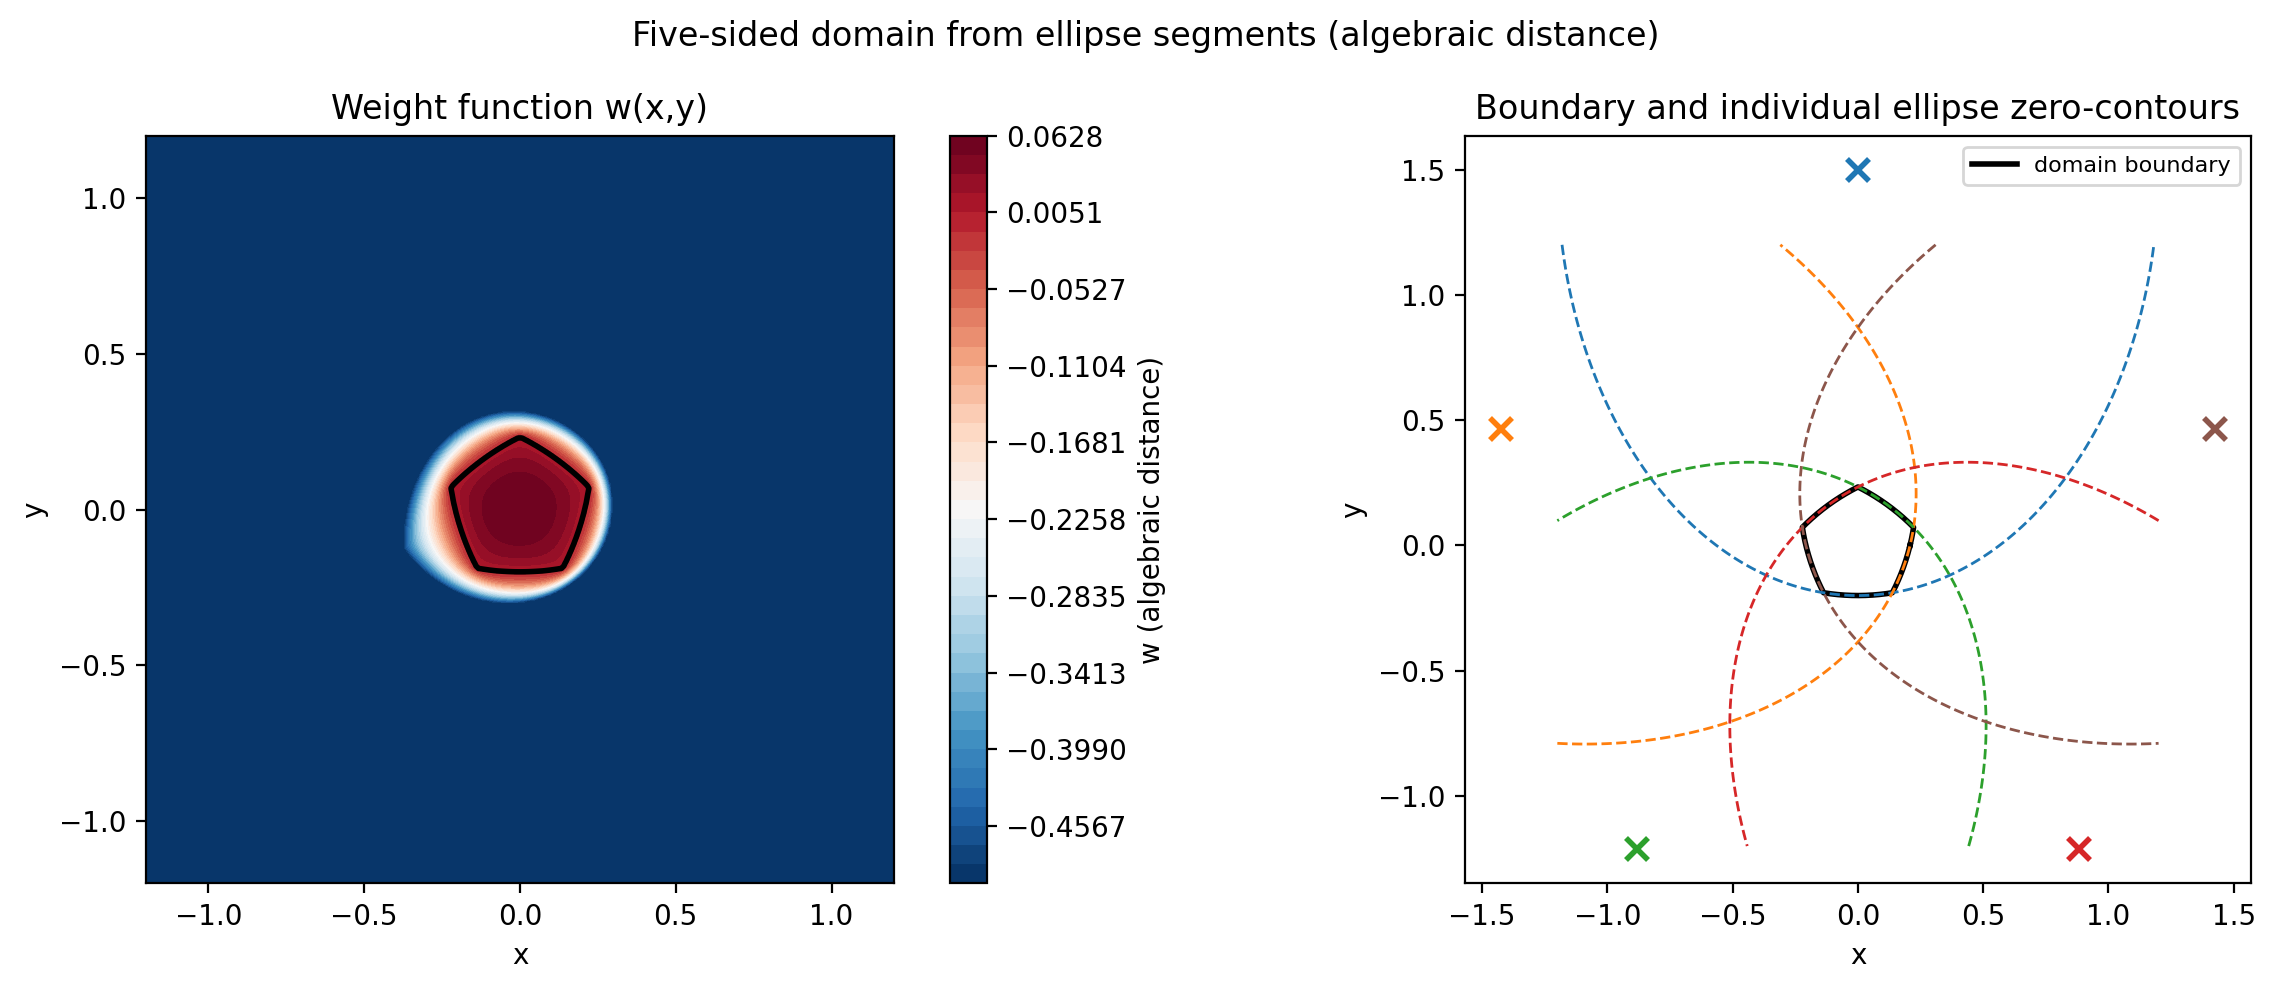

Boundary points: 500
w at boundary: min=7.90e-06, max=1.01e-03


In [3]:
# ==========================================================================
# Geometry: five-sided domain from ellipse segments (algebraic distance)
# ==========================================================================

ellipse_model = geom.AnaliticalDistanceEllipsePentagon_RFunction(
    n_sides=5,
    # Need enough overlap so the intersection (w>0) is non-empty.
    center_distance=1.5,
    semi_axis_tangential=1.2,
    semi_axis_radial=1.7,
    rotation_offset=np.pi / 2,
    preserve_zero_line=True,
    eps=1e-6,
)

GEOMS = [
    GeometryVariant(
        name="ellipse pentagon (algebraic dist, R-function)",
        model=ellipse_model,
        domain=DOMAIN_M11,
    ),
]

# Visualize the geometry: weight function contours and boundary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: weight function w(x,y) with level curves
ax = axes[0]
x = np.linspace(-1.2, 1.2, 300)
y = np.linspace(-1.2, 1.2, 300)
xg, yg = np.meshgrid(x, y)
coords = torch.tensor(np.stack([xg, yg], axis=-1), dtype=torch.float64)
with torch.no_grad():
    w_vis = ellipse_model(coords).numpy()
w_vis_clipped = np.clip(w_vis, -0.5, 0.5)

# Robust contour levels: Matplotlib requires strictly increasing levels.
vmin = float(np.nanmin(w_vis_clipped))
vmax = float(np.nanmax(w_vis_clipped))
if (not np.isfinite(vmin)) or (not np.isfinite(vmax)):
    vmin, vmax = -0.5, 0.5
if np.isclose(vmin, vmax):
    # When the field is (nearly) constant after clipping, expand a tiny bit.
    delta = 1e-6 if abs(vmin) < 1.0 else 1e-6 * abs(vmin)
    vmin -= delta
    vmax += delta
if vmin > vmax:
    vmin, vmax = vmax, vmin
levels = np.linspace(vmin, vmax, 40)
levels = np.unique(levels)
if levels.size < 2:
    levels = np.array([vmin, vmax], dtype=float)

cf = ax.contourf(xg, yg, w_vis_clipped, levels=levels, cmap="RdBu_r")
ax.contour(xg, yg, w_vis, levels=[0.0], colors="k", linewidths=2.0)
fig.colorbar(cf, ax=ax, label="w (algebraic distance)")
ax.set_aspect("equal")
ax.set_title("Weight function w(x,y)")
ax.set_xlabel("x"); ax.set_ylabel("y")

# Right: boundary + individual ellipse zero-level curves
ax = axes[1]
bp = ellipse_model._boundary_pts
ax.plot(np.append(bp[:, 0], bp[0, 0]), np.append(bp[:, 1], bp[0, 1]),
        'k-', linewidth=2, label='domain boundary')
colors = plt.cm.tab10(np.linspace(0, 0.5, 5))
for k in range(5):
    dists_k = ellipse_model.algebraic_distances_numpy(xg.ravel(), yg.ravel())
    Fk = dists_k[k].reshape(xg.shape)
    ax.contour(xg, yg, Fk, levels=[0.0], colors=[colors[k]], linewidths=1.0, linestyles='--')
    ax.plot(ellipse_model._centers_np[k, 0], ellipse_model._centers_np[k, 1],
            'x', color=colors[k], ms=8, mew=2)
ax.set_aspect("equal")
ax.set_title("Boundary and individual ellipse zero-contours")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8)

fig.suptitle("Five-sided domain from ellipse segments (algebraic distance)", fontsize=12)
fig.tight_layout()
plt.show()

# Verify the boundary is at w=0
print(f"Boundary points: {bp.shape[0]}")
crd_bp = torch.tensor(bp, dtype=torch.float64)
with torch.no_grad():
    w_bp = ellipse_model(crd_bp).numpy()
print(f"w at boundary: min={np.min(np.abs(w_bp)):.2e}, max={np.max(np.abs(w_bp)):.2e}")

In [4]:
# Debug: confirm collocation_2d return signature in *this* kernel
import inspect
print('colloc module:', getattr(colloc, '__file__', None))
print('collocation_2d signature:', inspect.signature(colloc.collocation_2d))
src = inspect.getsource(colloc.collocation_2d)
print('has return_coefficients branch:', ('if return_coefficients' in src) and ('recon_info' in src))

colloc module: c:\Egyetem\Kutatás\NeuralIGA\Neural Analysis\collocation_WEB.py
collocation_2d signature: (n: int, H: int, wfct: collocation_WEB.WeightFunction, f: Callable[[numpy.ndarray, numpy.ndarray], numpy.ndarray], CD: Optional[Dict] = None, verbose: bool = True, domain: Optional[Dict[str, float]] = None, solve_method: str = 'auto', dense_threshold: int = 2000, g: Optional[Callable[[numpy.ndarray, numpy.ndarray], numpy.ndarray]] = None, gx: Optional[Callable[[numpy.ndarray, numpy.ndarray], numpy.ndarray]] = None, gy: Optional[Callable[[numpy.ndarray, numpy.ndarray], numpy.ndarray]] = None, gxx: Optional[Callable[[numpy.ndarray, numpy.ndarray], numpy.ndarray]] = None, gyy: Optional[Callable[[numpy.ndarray, numpy.ndarray], numpy.ndarray]] = None, return_coefficients: bool = False)
has return_coefficients branch: True


In [5]:
# Debug: check weight function sign/scale on the unit grid mapped to the physical domain
wfct_grid_dbg = colloc.NeuralWeightFunction(ellipse_model, domain=DOMAIN_M11, transform=None)
uu = np.linspace(0.0, 1.0, 80)
uu_xg, uu_yg = np.meshgrid(uu, uu, indexing='ij')
w_dbg, *_ = wfct_grid_dbg(uu_xg, uu_yg)
print('w_dbg: min/max =', float(np.nanmin(w_dbg)), float(np.nanmax(w_dbg)))
print('w_dbg: frac(w>0) =', float(np.mean(w_dbg > 0)))

# Also sample the model directly in physical coordinates
pts_phys = torch.tensor([[0.0, 0.0], [0.5, 0.0], [0.0, 0.5], [-0.5, 0.0], [0.0, -0.5]], dtype=torch.float64)
with torch.no_grad():
    vals_phys = ellipse_model(pts_phys).cpu().numpy().ravel()
print('ellipse_model at sample phys points:', vals_phys)

w_dbg: min/max = -54.06286415681224 0.06262677315281326
w_dbg: frac(w>0) = 0.0340625
ellipse_model at sample phys points: [ 0.06277275 -5.33496738 -2.60138258 -1.33620776 -4.81441272]


In [6]:
# Debug: does the model expect unit-square coords instead of physical coords?
wfct_unit = colloc.NeuralWeightFunction(ellipse_model, domain=None, transform=None)
uu = np.linspace(0.0, 1.0, 80)
ux, uy = np.meshgrid(uu, uu, indexing='ij')
w_unit, *_ = wfct_unit(ux, uy)
print('w_unit (domain=None): min/max =', float(np.nanmin(w_unit)), float(np.nanmax(w_unit)))
print('w_unit: frac(w>0) =', float(np.mean(w_unit > 0)))

pts_unit = torch.tensor([[0.5, 0.5], [0.2, 0.5], [0.5, 0.2], [0.8, 0.5], [0.5, 0.8]], dtype=torch.float64)
with torch.no_grad():
    vals_unit = ellipse_model(pts_unit).cpu().numpy().ravel()
print('ellipse_model at sample unit points:', vals_unit)

w_unit (domain=None): min/max = -37.62658391622749 0.06277274822883985
w_unit: frac(w>0) = 0.0375
ellipse_model at sample unit points: [ -8.51985111  -3.67540803  -5.36435657 -18.12709398 -14.24585142]


In [7]:
# Quick sanity: choose center_distance <= semi_axis_radial to get a non-empty intersection near the origin
test_model = geom.AnaliticalDistanceEllipsePentagon_RFunction(
    n_sides=5,
    center_distance=0.8,
    semi_axis_tangential=1.2,
    semi_axis_radial=0.85,
    rotation_offset=np.pi / 2,
    preserve_zero_line=True,
    eps=1e-6,
 )
wfct_test = colloc.NeuralWeightFunction(test_model, domain=DOMAIN_M11, transform=None)
uu = np.linspace(0.0, 1.0, 120)
ux, uy = np.meshgrid(uu, uu, indexing='ij')
w_test, *_ = wfct_test(ux, uy)
print('test_model w on DOMAIN_M11: min/max =', float(np.nanmin(w_test)), float(np.nanmax(w_test)))
print('test_model frac(w>0) =', float(np.mean(w_test > 0)))
with torch.no_grad():
    w0 = test_model(torch.tensor([[0.0, 0.0]], dtype=torch.float64)).item()
print('test_model w(0,0) =', w0)

test_model w on DOMAIN_M11: min/max = -130.38883223762463 0.03151416256932055
test_model frac(w>0) = 0.0022222222222222222
test_model w(0,0) = 0.0323605418128267


In [8]:
# Quick sanity 2: keep center_distance=1.5 but increase radial semi-axis to get overlap
test_model2 = geom.AnaliticalDistanceEllipsePentagon_RFunction(
    n_sides=5,
    center_distance=1.5,
    semi_axis_tangential=1.2,
    semi_axis_radial=1.7,
    rotation_offset=np.pi / 2,
    preserve_zero_line=True,
    eps=1e-6,
 )
wfct_test2 = colloc.NeuralWeightFunction(test_model2, domain=DOMAIN_M11, transform=None)
uu = np.linspace(0.0, 1.0, 120)
ux, uy = np.meshgrid(uu, uu, indexing='ij')
w_test2, *_ = wfct_test2(ux, uy)
print('test_model2 w on DOMAIN_M11: min/max =', float(np.nanmin(w_test2)), float(np.nanmax(w_test2)))
print('test_model2 frac(w>0) =', float(np.mean(w_test2 > 0)))
with torch.no_grad():
    w0_2 = test_model2(torch.tensor([[0.0, 0.0]], dtype=torch.float64)).item()
print('test_model2 w(0,0) =', w0_2)

test_model2 w on DOMAIN_M11: min/max = -54.06286415681224 0.0627446213774479
test_model2 frac(w>0) = 0.034444444444444444
test_model2 w(0,0) = 0.06277274822883985


In [9]:
# Check WEB classification prerequisites for test_model2 at n=2, H=32
n_chk, H_chk = 2, 32
CD_chk = colloc.compute_collocation_data(n_chk, J_MAX=16)
bw = int(CD_chk['bw'])
t_start_val = -(n_chk - 1) / 2 - bw
t_end_val = H_chk + (n_chk - 1) / 2 + bw
t_range = np.arange(t_start_val, t_end_val + 1, dtype=np.float64)
t = t_range / H_chk
x_grid, y_grid = np.meshgrid(t, t, indexing='ij')
wf_chk = colloc.NeuralWeightFunction(test_model2, domain=DOMAIN_M11, transform=None)
w_ext, *_ = wf_chk(x_grid, y_grid)
indB = np.arange(bw, H_chk + n_chk + bw)
wB = w_ext[indB, :][:, indB]
Btype_inner = wB > 0
mi = int(np.sum(Btype_inner))
eI = np.ones((H_chk, H_chk), dtype=bool)
for s1 in range(n_chk + 1):
    for s2 in range(n_chk + 1):
        eI = eI & Btype_inner[s1:s1 + H_chk, s2:s2 + H_chk]
print('test_model2: mi(inner splines)=', mi, ' | any fully-inner blocks=', bool(np.any(eI)))

test_model2: mi(inner splines)= 32  | any fully-inner blocks= True


In [10]:
# ==========================================================================
# Collocation sweep: run solver for each (n, H) combination
# ==========================================================================

import importlib
importlib.reload(colloc)

def run_one(geom_variant, n, H, CD_cache, verbose=False):
    """Run collocation and return result dict."""
    f_phys, u_exact_phys, wfct_phys = make_manufactured_problem(
        geom_variant.model, u_type=U_EXACT_TYPE)

    wfct_grid = colloc.NeuralWeightFunction(
        geom_variant.model, domain=geom_variant.domain, transform=None)

    if n not in CD_cache:
        CD_cache[n] = colloc.compute_collocation_data(n, J_MAX=16)

    out = colloc.collocation_2d(
        n=n, H=H, wfct=wfct_grid, f=f_phys, CD=CD_cache[n],
        verbose=verbose, domain=geom_variant.domain,
        solve_method="auto", dense_threshold=2000,
        g=zero_fn, gx=zero_fn, gy=zero_fn, gxx=zero_fn, gyy=zero_fn,
        return_coefficients=True)

    if not (isinstance(out, tuple) and len(out) == 7):
        raise ValueError(
            f"collocation_2d(..., return_coefficients=True) returned {len(out) if isinstance(out, tuple) else type(out)} values; expected 7."
        )

    Uxy, xB, yB, con, dim_sys, rtimes, recon_info = out
    if Uxy is None or xB is None or yB is None or recon_info is None:
        raise RuntimeError(
            "collocation_2d failed (returned no solution). "
            "This usually means H is too small for this geometry/degree (no fully-inner blocks), "
            "or the weight function sign is wrong (w>0 should be inside)."
        )

    xP, yP = transform_grid_to_physical(xB, yB, geom_variant.domain)
    wP, *_ = wfct_phys(xP, yP)
    uex = u_exact_phys(xP, yP)

    # Algebraic SDF (min algebraic distance) for near-boundary binning
    sdf_P = geom_variant.model.min_algebraic_distance_numpy(xP, yP)

    err = np.abs(Uxy - uex)
    inside = wP > 0
    err_inside = err[inside]
    sdf_inside = sdf_P[inside]

    summary = {
        "geom": geom_variant.name, "u_exact": U_EXACT_TYPE,
        "n": int(n), "H": int(H), "dim_sys": int(dim_sys),
        "con": float(con) if con is not None else np.nan,
        "err_mean": float(np.mean(err_inside)) if err_inside.size else np.nan,
        "err_max": float(np.max(err_inside)) if err_inside.size else np.nan,
        "inside_count": int(err_inside.size),
        "status": "ok",
    }

    bins = compute_near_boundary_binning(sdf_inside, err_inside, n_bins=30)

    return {
        "summary": summary, "Uxy": Uxy, "xP": xP, "yP": yP,
        "wP": wP, "err": err, "inside": inside, "bins": bins,
        "u_exact_phys": u_exact_phys, "wfct_phys": wfct_phys,
        "recon_info": recon_info, "model": geom_variant.model,
    }


# --- Main sweep ---
CD_cache = {}
all_summaries = []
all_results = {}

for gv in GEOMS:
    for n in DEGREES:
        for H in HS:
            key = (gv.name, n, H)
            print(f"Running: geom={gv.name} | n={n} | H={H}")
            try:
                res = run_one(gv, n=n, H=H, CD_cache=CD_cache, verbose=False)
            except Exception as e:
                all_summaries.append({
                    "geom": gv.name, "u_exact": U_EXACT_TYPE,
                    "n": int(n), "H": int(H),
                    "dim_sys": 0, "con": np.nan,
                    "err_mean": np.nan, "err_max": np.nan, "inside_count": 0,
                    "status": "fail", "error": str(e),
                })
                continue
            all_results[key] = res
            all_summaries.append(res["summary"])

summary_df = pd.DataFrame(all_summaries)
summary_df = summary_df.sort_values(["geom", "n", "H"]).reset_index(drop=True)
display(summary_df)

Running: geom=ellipse pentagon (algebraic dist, R-function) | n=2 | H=32
Running: geom=ellipse pentagon (algebraic dist, R-function) | n=2 | H=64
Running: geom=ellipse pentagon (algebraic dist, R-function) | n=2 | H=128
Running: geom=ellipse pentagon (algebraic dist, R-function) | n=3 | H=32
Running: geom=ellipse pentagon (algebraic dist, R-function) | n=3 | H=64
Running: geom=ellipse pentagon (algebraic dist, R-function) | n=3 | H=128
Running: geom=ellipse pentagon (algebraic dist, R-function) | n=4 | H=32
Error: Grid width 1/H too large - no fully inner element arrays
Running: geom=ellipse pentagon (algebraic dist, R-function) | n=4 | H=64
Running: geom=ellipse pentagon (algebraic dist, R-function) | n=4 | H=128


,geom,u_exact,n,H,dim_sys,con,err_mean,err_max,inside_count,status,error
0,"ellipse pentagon (algebraic dist, R-function)",expw,2,32,32,16.487337,3.719727e-05,0.000078,32,ok,NaN
1,"ellipse pentagon (algebraic dist, R-function)",expw,2,64,144,50.120017,1.053465e-05,0.000029,144,ok,NaN
2,"ellipse pentagon (algebraic dist, R-function)",expw,2,128,574,161.068219,3.460218e-06,0.000006,574,ok,NaN
3,"ellipse pentagon (algebraic dist, R-function)",expw,3,32,39,5906.976940,3.898558e-04,0.002159,39,ok,NaN
4,"ellipse pentagon (algebraic dist, R-function)",expw,3,64,146,378.606255,1.141492e-05,0.000020,146,ok,NaN
5,"ellipse pentagon (algebraic dist, R-function)",expw,3,128,571,301.357319,3.912382e-06,0.000010,571,ok,NaN
6,"ellipse pentagon (algebraic dist, R-function)",expw,4,32,0,NaN,NaN,NaN,0,fail,collocation_2d failed (returned no solution). ...
7,"ellipse pentagon (algebraic dist, R-function)",expw,4,64,144,1242.321372,4.219119e-06,0.000015,144,ok,NaN
8,"ellipse pentagon (algebraic dist, R-function)",expw,4,128,574,2984.533654,2.501698e-07,0.000003,574,ok,NaN


C:\Users\csapo\AppData\Local\Temp\ipykernel_20576\513397678.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf.collections:


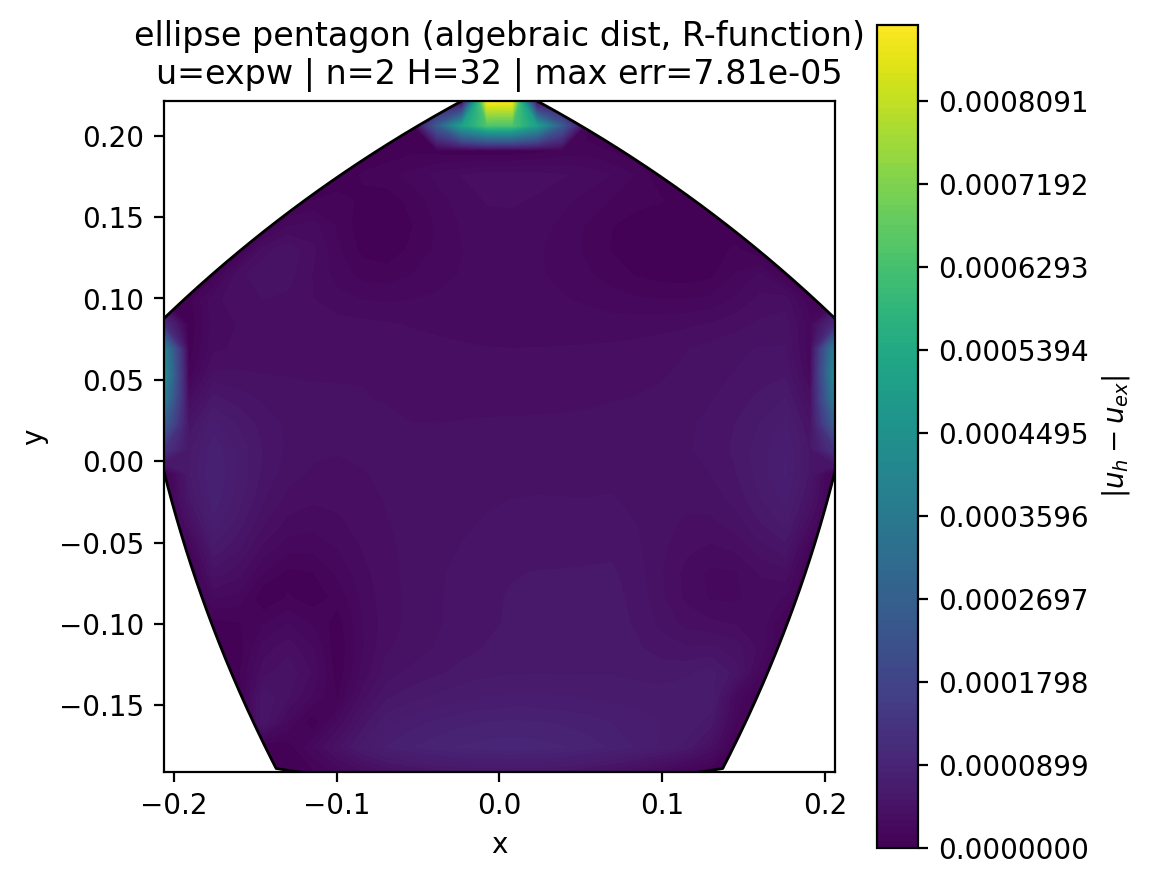

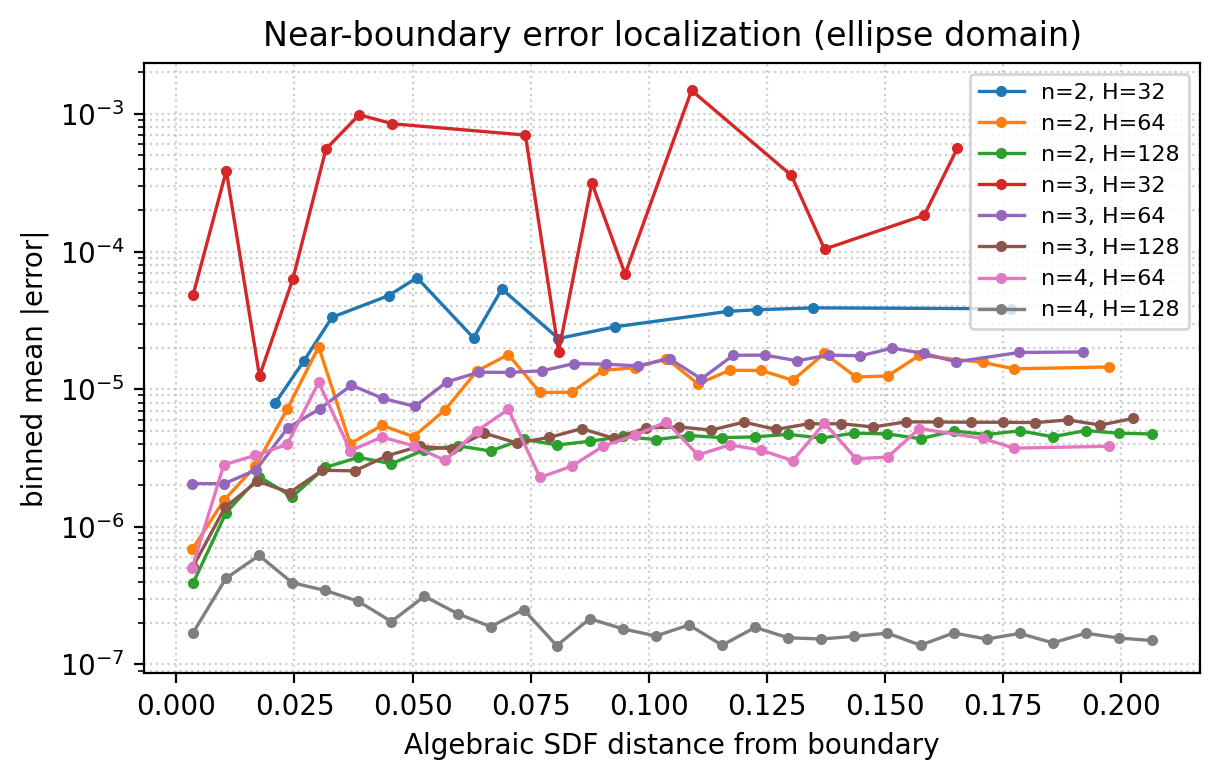

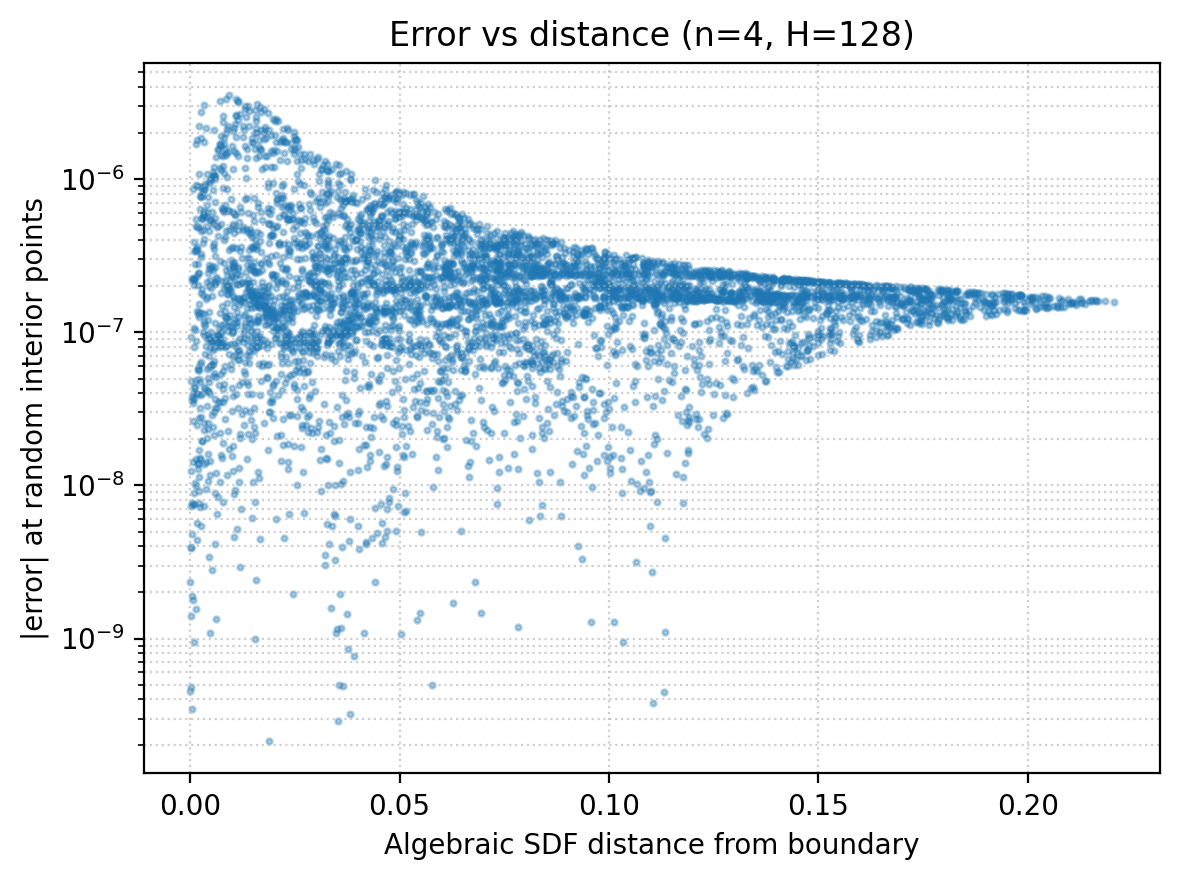

In [11]:
# ==========================================================================
# Solution error: heatmaps, scatter plots, near-boundary binning
# ==========================================================================

def plot_error_field_ellipse(res, title: str):
    """Error heatmap clipped to the ellipse-segment boundary."""
    xP, yP, Uxy = res["xP"], res["yP"], res["Uxy"]
    u_exact_phys = res["u_exact_phys"]
    wfct_phys = res["wfct_phys"]
    model = res["model"]
    recon_info = res["recon_info"]
    boundary_pts = model._boundary_pts

    # Fine grid + B-spline reconstruction
    x1d = np.linspace(float(np.min(xP)), float(np.max(xP)),
                      xP.shape[1] * int(PLOT_UPSAMPLE))
    y1d = np.linspace(float(np.min(yP)), float(np.max(yP)),
                      xP.shape[0] * int(PLOT_UPSAMPLE))
    xPu, yPu = np.meshgrid(x1d, y1d)
    Uh_u = colloc.reconstruct_collocation_at_points(
        xPu.ravel(), yPu.ravel(), recon_info, wfct_phys
    ).reshape(xPu.shape)

    w_u, *_ = wfct_phys(xPu, yPu)
    Uex_u = u_exact_phys(xPu, yPu)
    err_u = np.abs(Uh_u - Uex_u)
    inside_u = w_u > 0

    err_plot = err_u.copy()
    err_plot[~inside_u] = 0.0

    fig, ax = plt.subplots(figsize=(5.8, 5.0))
    emax = float(np.max(err_u[inside_u])) if np.any(inside_u) else 1e-10
    im = ax.contourf(xPu, yPu, err_plot,
                     levels=np.linspace(0, emax, int(CONTOUR_LEVELS)))
    _clip_contourf_to_boundary(im, ax, boundary_pts)
    fig.colorbar(im, ax=ax, label=r"$|u_h-u_{ex}|$")

    # Draw boundary
    bp = boundary_pts
    ax.plot(np.append(bp[:, 0], bp[0, 0]),
            np.append(bp[:, 1], bp[0, 1]),
            'k-', linewidth=1.0)

    _zoom_axes_to_domain(ax, xPu, yPu, inside_u)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()


def plot_near_boundary_curves(bin_dfs, labels, title):
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for df, lab in zip(bin_dfs, labels):
        if df.empty:
            continue
        ax.plot(df["w_mid"], df["err_mean"], marker="o", ms=3, lw=1.2, label=lab)
    ax.set_yscale("log")
    ax.set_xlabel("Algebraic SDF distance from boundary")
    ax.set_ylabel("binned mean |error|")
    ax.grid(True, which="both", ls=":", alpha=0.6)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


def _pick_available_key(geom_name: str, prefer_max: bool = False):
    keys = [k for k in all_results.keys() if k[0] == geom_name]
    if not keys:
        return None
    keys = sorted(keys, key=lambda k: (k[1], k[2]))
    return keys[-1] if prefer_max else keys[0]


# --- Error heatmaps ---
n_show = DEGREES[0]
H_show = HS[0]

for gv in GEOMS:
    key = (gv.name, n_show, H_show)
    if key not in all_results:
        key = _pick_available_key(gv.name, prefer_max=False)
    if key is None:
        continue
    res = all_results[key]
    s = res["summary"]
    plot_error_field_ellipse(
        res,
        title=f"{gv.name}\nu={U_EXACT_TYPE} | n={key[1]} H={key[2]} | max err={s['err_max']:.2e}",
    )

# --- Near-boundary binning curves across (n, H) ---
bin_dfs = []
labels = []
for n in DEGREES:
    for H in HS:
        key = (GEOMS[0].name, n, H)
        if key not in all_results:
            continue
        res = all_results[key]
        bin_dfs.append(res["bins"])
        labels.append(f"n={n}, H={H}")
plot_near_boundary_curves(
    bin_dfs, labels,
    title="Near-boundary error localization (ellipse domain)")

# --- Scatter: error vs algebraic SDF (random interior points) ---
N_RANDOM = 5000
RNG = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(6, 4.5))

gv = GEOMS[0]
key = _pick_available_key(gv.name, prefer_max=True)
if key is None:
    raise RuntimeError("No successful collocation runs found in all_results.")
res = all_results[key]
recon_info = res["recon_info"]
wfct_phys = res["wfct_phys"]
u_exact_phys = res["u_exact_phys"]
model_geo = res["model"]

bp = model_geo._boundary_pts
xmin, xmax = float(bp[:, 0].min()) - 0.1, float(bp[:, 0].max()) + 0.1
ymin, ymax = float(bp[:, 1].min()) - 0.1, float(bp[:, 1].max()) + 0.1

pts_x, pts_y = [], []
while len(pts_x) < N_RANDOM:
    batch = max(N_RANDOM * 5, 10000)
    rx = RNG.uniform(xmin, xmax, size=batch)
    ry = RNG.uniform(ymin, ymax, size=batch)
    w_s, *_ = wfct_phys(rx, ry)
    mask = w_s > 0
    pts_x.extend(rx[mask].tolist())
    pts_y.extend(ry[mask].tolist())
pts_x = np.asarray(pts_x[:N_RANDOM], dtype=np.float64)
pts_y = np.asarray(pts_y[:N_RANDOM], dtype=np.float64)

u_h = colloc.reconstruct_collocation_at_points(pts_x, pts_y, recon_info, wfct_phys)
u_ex = u_exact_phys(pts_x, pts_y)
err = np.abs(u_h - u_ex)
sdf = model_geo.min_algebraic_distance_numpy(pts_x, pts_y)

ax.scatter(sdf, err, s=4, alpha=0.35)
ax.set_yscale("log")
ax.set_xlabel("Algebraic SDF distance from boundary")
ax.set_ylabel("|error| at random interior points")
ax.grid(True, which="both", ls=":", alpha=0.6)
ax.set_title(f"Error vs distance (n={key[1]}, H={key[2]})")
fig.tight_layout()
plt.show()


ellipse pentagon (algebraic dist, R-function) | u=expw | n=4 H=128
  u_x    max=3.534e-04  mean=1.110e-05
  u_y    max=1.820e-03  mean=1.133e-05
  u_xx   max=1.785e-01  mean=1.889e-03
  u_yy   max=7.464e-01  mean=2.566e-03


C:\Users\csapo\AppData\Local\Temp\ipykernel_20576\513397678.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf.collections:


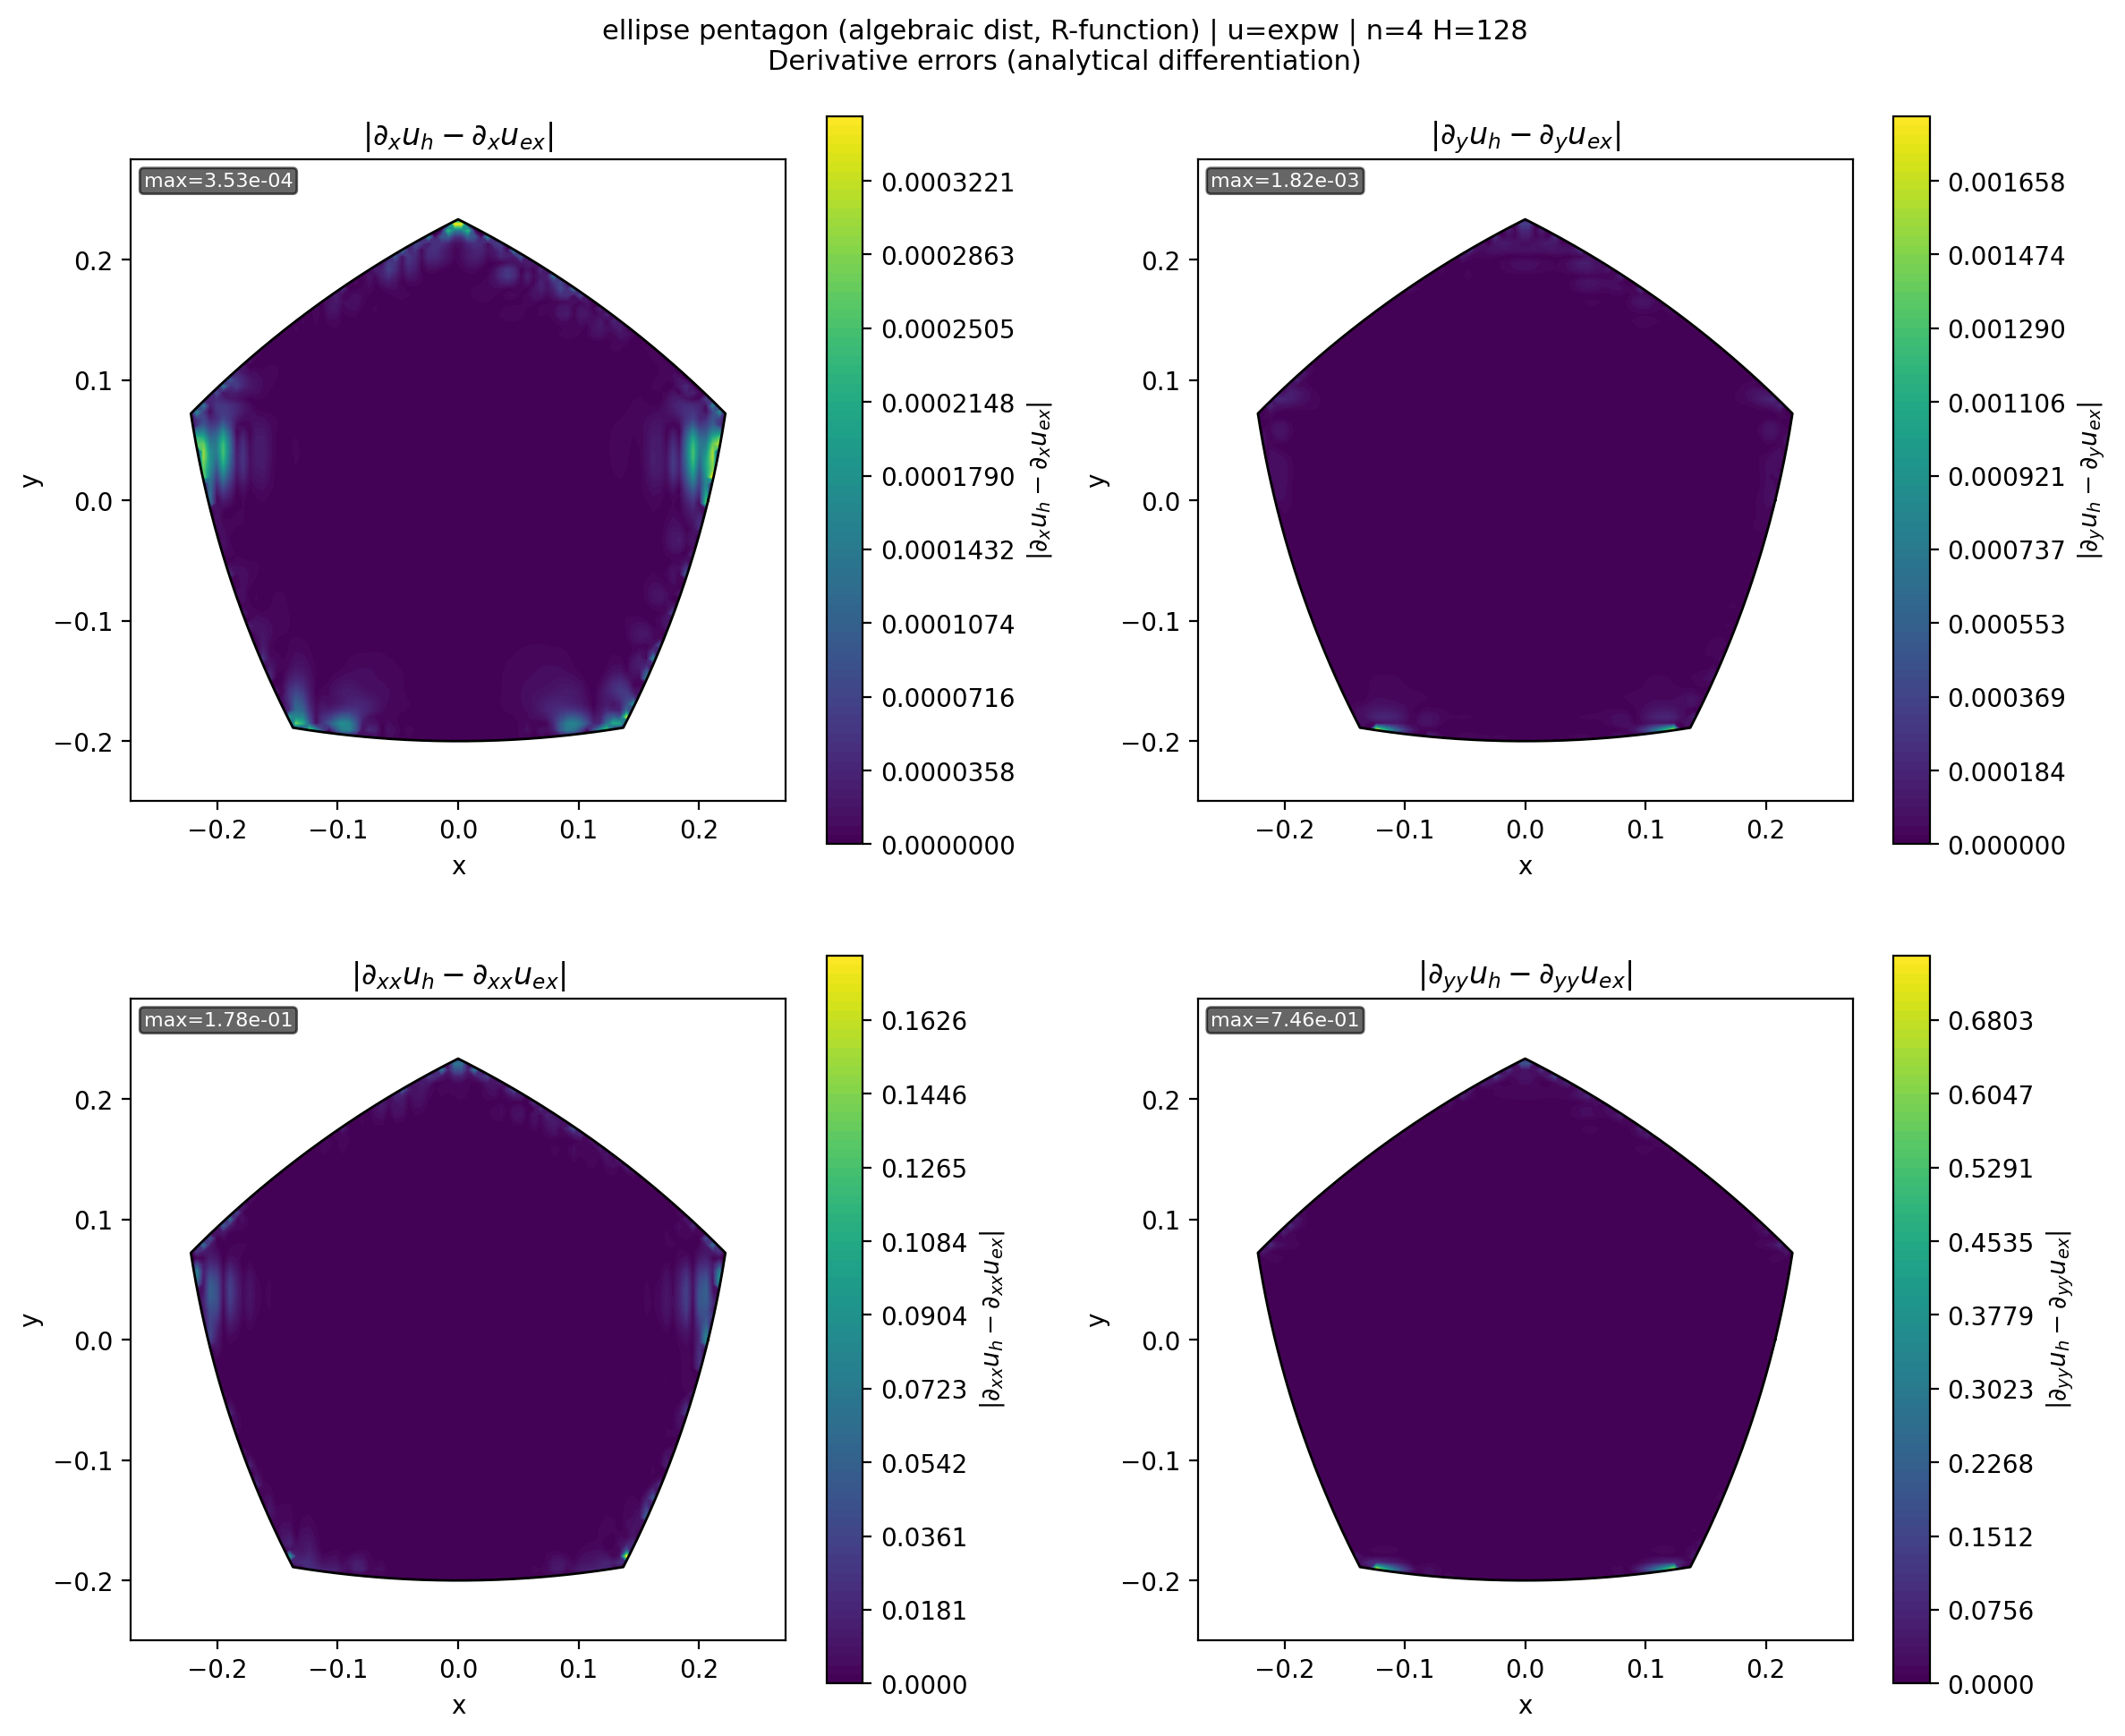

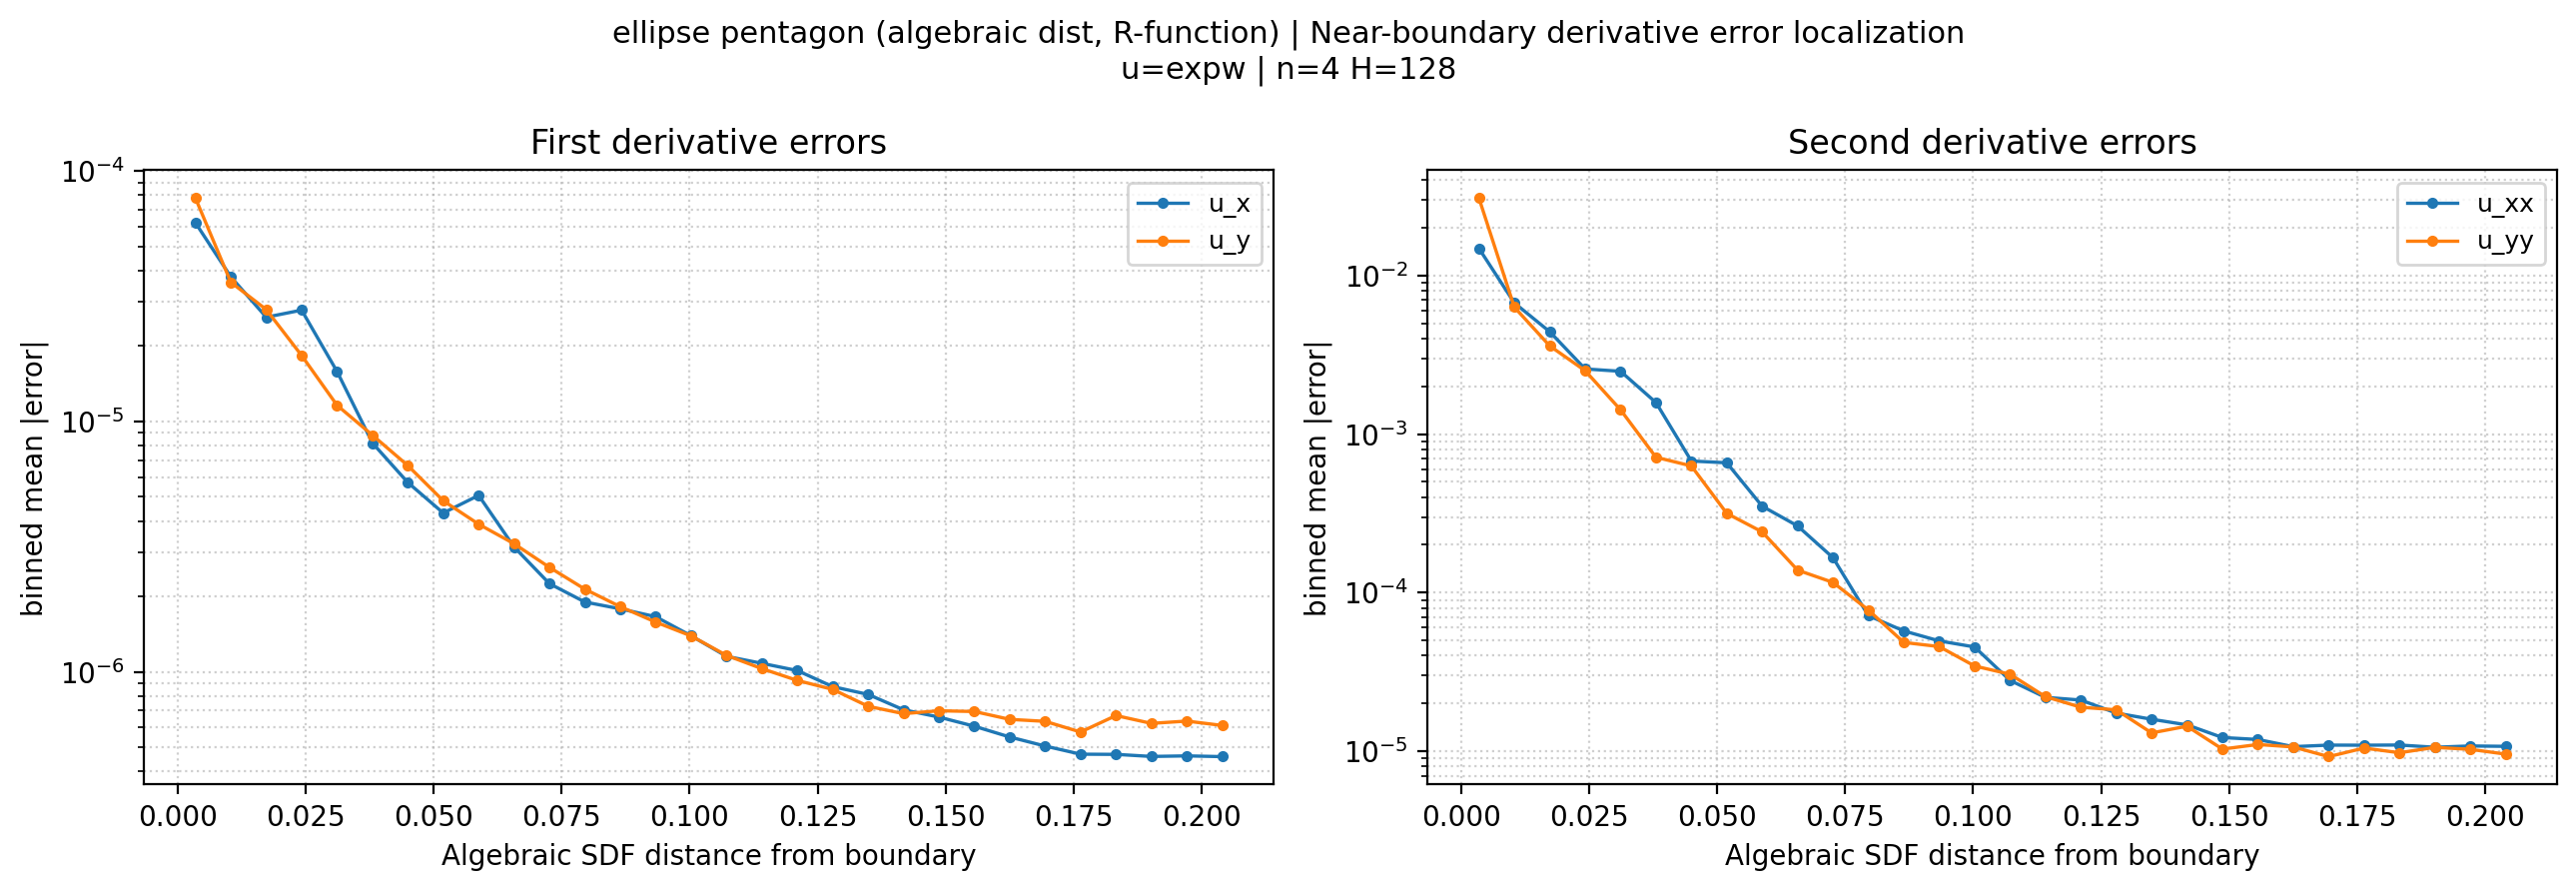

In [12]:
# ==========================================================================
# DERIVATIVE ERROR ANALYSIS (first and second derivatives)
# ==========================================================================
# Exact solution derivatives (u = exp(w) - 1):
#   u_x   = exp(w) * w_x
#   u_y   = exp(w) * w_y
#   u_xx  = exp(w) * (w_x^2 + w_xx)
#   u_yy  = exp(w) * (w_y^2 + w_yy)
#
# Numerical solution derivatives: analytical via B-spline differentiation
# (reconstruct_collocation_hessian_diag).

n_d = DEGREES[-1]
H_d = HS[-1]
GRID_RES = 100

all_deriv_bins = {}

for gv in GEOMS:
    res = all_results[(gv.name, n_d, H_d)]
    recon_info = res["recon_info"]
    wfct_phys = res["wfct_phys"]
    model_geo = res["model"]
    boundary_pts = model_geo._boundary_pts

    # Fine evaluation grid
    bp = model_geo._boundary_pts
    xmin_v = float(bp[:, 0].min()) - 0.05
    xmax_v = float(bp[:, 0].max()) + 0.05
    ymin_v = float(bp[:, 1].min()) - 0.05
    ymax_v = float(bp[:, 1].max()) + 0.05
    gx = np.linspace(xmin_v, xmax_v, GRID_RES)
    gy = np.linspace(ymin_v, ymax_v, GRID_RES)
    GX, GY = np.meshgrid(gx, gy)
    flat_x, flat_y = GX.ravel(), GY.ravel()

    # Numerical derivatives (analytical via B-spline basis + product rule)
    u_h, ux_h, uy_h, uxx_h, uyy_h = colloc.reconstruct_collocation_hessian_diag(
        flat_x, flat_y, recon_info, wfct_phys)

    # Exact derivatives
    ux_ex, uy_ex, uxx_ex, uyy_ex = compute_exact_derivatives(
        wfct_phys, flat_x, flat_y, U_EXACT_TYPE)

    # Inside-domain mask
    w_vals, *_ = wfct_phys(flat_x, flat_y)
    w_vals = np.asarray(w_vals).ravel()
    inside = w_vals > 0
    valid_grid = inside.reshape(GX.shape)

    # Derivative errors
    deriv_data = [
        (r"$|\partial_x u_h - \partial_x u_{ex}|$", "u_x", np.abs(ux_h - ux_ex)),
        (r"$|\partial_y u_h - \partial_y u_{ex}|$", "u_y", np.abs(uy_h - uy_ex)),
        (r"$|\partial_{xx} u_h - \partial_{xx} u_{ex}|$", "u_xx", np.abs(uxx_h - uxx_ex)),
        (r"$|\partial_{yy} u_h - \partial_{yy} u_{ex}|$", "u_yy", np.abs(uyy_h - uyy_ex)),
    ]

    # Algebraic SDF for near-boundary binning
    sdf_flat = model_geo.min_algebraic_distance_numpy(flat_x, flat_y)
    sdf_inside = sdf_flat[inside]

    # --- Print summary ---
    print(f"\n{'='*70}")
    print(f"{gv.name} | u={U_EXACT_TYPE} | n={n_d} H={H_d}")
    print(f"{'='*70}")
    for latex_label, short_label, err_flat in deriv_data:
        ei = err_flat[inside]
        print(f"  {short_label:5s}  max={np.max(ei):.3e}  mean={np.mean(ei):.3e}")

    # --- Heatmap: 2x2 grid of derivative errors ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, (latex_label, short_label, err_flat) in zip(axes.ravel(), deriv_data):
        err_grid = err_flat.reshape(GX.shape)
        err_plot = err_grid.copy()
        err_plot[~valid_grid] = 0.0
        ei = err_flat[inside]
        emax = float(np.max(ei)) if ei.size else 1e-10
        im = ax.contourf(GX, GY, err_plot,
                         levels=np.linspace(0, emax, 80))
        _clip_contourf_to_boundary(im, ax, boundary_pts)
        fig.colorbar(im, ax=ax, label=latex_label)
        # Draw boundary
        ax.plot(np.append(bp[:, 0], bp[0, 0]),
                np.append(bp[:, 1], bp[0, 1]),
                'k-', linewidth=1.0)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(latex_label)
        ax.set_xlabel("x"); ax.set_ylabel("y")
        ax.text(0.02, 0.98, f"max={emax:.2e}", transform=ax.transAxes,
                va="top", ha="left", fontsize=8, color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6))

    fig.suptitle(
        f"{gv.name} | u={U_EXACT_TYPE} | n={n_d} H={H_d}\n"
        "Derivative errors (analytical differentiation)", fontsize=11)
    fig.tight_layout()
    plt.show()

    # --- Binned error vs SDF for first and second derivatives ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    for latex_label, short_label, err_flat in deriv_data[:2]:
        bins = compute_near_boundary_binning(sdf_inside, err_flat[inside], n_bins=30)
        all_deriv_bins[(gv.name, short_label)] = bins
        if not bins.empty:
            ax1.plot(bins["w_mid"], bins["err_mean"],
                     marker="o", ms=3, lw=1.2, label=short_label)
    ax1.set_yscale("log")
    ax1.set_xlabel("Algebraic SDF distance from boundary")
    ax1.set_ylabel("binned mean |error|")
    ax1.set_title("First derivative errors")
    ax1.legend(fontsize=9)
    ax1.grid(True, which="both", ls=":", alpha=0.6)

    for latex_label, short_label, err_flat in deriv_data[2:]:
        bins = compute_near_boundary_binning(sdf_inside, err_flat[inside], n_bins=30)
        all_deriv_bins[(gv.name, short_label)] = bins
        if not bins.empty:
            ax2.plot(bins["w_mid"], bins["err_mean"],
                     marker="o", ms=3, lw=1.2, label=short_label)
    ax2.set_yscale("log")
    ax2.set_xlabel("Algebraic SDF distance from boundary")
    ax2.set_ylabel("binned mean |error|")
    ax2.set_title("Second derivative errors")
    ax2.legend(fontsize=9)
    ax2.grid(True, which="both", ls=":", alpha=0.6)

    fig.suptitle(
        f"{gv.name} | Near-boundary derivative error localization\n"
        f"u={U_EXACT_TYPE} | n={n_d} H={H_d}", fontsize=11)
    fig.tight_layout()
    plt.show()

# SIREN neural correction for collocation solver (ellipse domain)

Ansatz: $u = u_{\text{colloc}} + \psi \cdot u_{\text{nn}}$ (psi-weighted correction)

where $\psi(x,y) = w(x,y) \cdot \varphi\!\bigl(\mathrm{SDF}(x,y)/\epsilon\bigr)$
with polynomial compact-support cutoff $\varphi(s) = \max(0,\, 1-s^2)^3$.

The SIREN neural network $u_{\text{nn}}$ takes as input the **algebraic distances**
from each of the 5 ellipses (analogous to halfplane distances for polygons).

**Key difference from polygon case:** the algebraic distance SDF has **non-zero second
derivatives** ($F_{xx}$, $F_{yy}$ are constant per ellipse), so the psi second derivatives
include an extra term:

$$\psi_{xx} = w_{xx}\,\varphi + 2\,w_x\,\varphi'\,s_x + w\,(\varphi''\,s_x^2 + \varphi'\,s_{xx})$$

where $s = \mathrm{SDF}/\epsilon$, $s_x = \mathrm{SDF}_x/\epsilon$, $s_{xx} = \mathrm{SDF}_{xx}/\epsilon$.

Training minimizes:
$\mathcal{L} = \| \Delta(\psi \cdot u_{\text{nn}}) + r_{\text{colloc}} \|^2$
where $r_{\text{colloc}} = \Delta u_{\text{colloc}} + f$ is the collocation PDE residual.

In [49]:
# ==========================================================================
# SIREN setup + pre-computation (ellipse domain)
# ==========================================================================
import time as _time

torch.set_default_dtype(torch.float64)
importlib.reload(network_defs)

# ---- Configuration ----
NUM_EPOCHS = 300
BATCH_SIZE = 2000
POOL_SIZE = 500000
EPS_BAND = 0.04
DOWNSCALE = 1.0

# Pick geometry and solver config for neural correction
CORR_GEOM_NAME = GEOMS[0].name
CORR_N = DEGREES[0]
CORR_H = HS[0]
CORR_KEY = (CORR_GEOM_NAME, CORR_N, CORR_H)
res_corr = all_results[CORR_KEY]
recon_info_corr = res_corr["recon_info"]
wfct_phys_corr = res_corr["wfct_phys"]
model_corr = res_corr["model"]
u_exact_phys_corr = res_corr["u_exact_phys"]
n_ellipses = model_corr.n_sides

print(f"Geometry: {CORR_GEOM_NAME}")
print(f"Collocation: n={CORR_N}, H={CORR_H}")
print(f"Ellipses: {n_ellipses}")
print(f"NN input dim: {n_ellipses} (algebraic distances)")

# Initialize SIREN model
model_nn = network_defs.Siren(
    architecture=[n_ellipses, 256, 256, 256, 1], outermost_linear=True,
    first_omega_0=20.0, hidden_omega_0=20.0
).double()

optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-6)
lr_sched = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50000, gamma=0.8)


Geometry: ellipse pentagon (algebraic dist, R-function)
Collocation: n=2, H=32
Ellipses: 5
NN input dim: 5 (algebraic distances)


In [40]:


# ---- Psi helper functions (adapted for ellipse: non-zero SDF second derivs) ----

def compute_phi_and_derivs(s):
    """Polynomial compact-support cutoff: phi(s) = max(0, 1-s^2)^3."""
    s = np.asarray(s, dtype=np.float64)
    t = np.clip(1.0 - s**2, 0.0, None)
    active = t > 0
    phi = t**3
    phi_prime = np.zeros_like(s)
    phi_prime[active] = -6.0 * s[active] * (1.0 - s[active]**2)**2
    phi_dbl = np.zeros_like(s)
    phi_dbl[active] = -6.0 * (1.0 - s[active]**2) * (1.0 - 5.0 * s[active]**2)
    return phi, phi_prime, phi_dbl


def compute_psi_all_ellipse(pts_x, pts_y, model, wfct_phys, eps_band):
    """Compute psi = w * phi(SDF/eps) and its first+second derivatives.

    KEY DIFFERENCE from polygon: SDF second derivatives (sdf_xx, sdf_yy) are NON-ZERO
    for elliptic algebraic distance. The psi_xx formula becomes:
        psi_xx = w_xx*phi + 2*w_x*phi'*sx + w*(phi''*sx^2 + phi'*sxx)

    where sxx = sdf_xx / eps_band is NON-ZERO (constant per closest ellipse).
    """
    w, wx, wy, wxx, wyy = wfct_phys(pts_x, pts_y)
    w = np.asarray(w, dtype=np.float64).ravel()
    wx = np.asarray(wx, dtype=np.float64).ravel()
    wy = np.asarray(wy, dtype=np.float64).ravel()
    wxx = np.asarray(wxx, dtype=np.float64).ravel()
    wyy = np.asarray(wyy, dtype=np.float64).ravel()

    # Compute algebraic SDF and its derivatives (including non-zero sdf_xx, sdf_yy)
    sdf, sdf_x, sdf_y, sdf_xx, sdf_yy = compute_algebraic_sdf_and_derivs(pts_x, pts_y, model)

    s = sdf / eps_band
    sx = sdf_x / eps_band
    sy = sdf_y / eps_band
    sxx = sdf_xx / eps_band   # NON-ZERO for ellipses!
    syy = sdf_yy / eps_band   # NON-ZERO for ellipses!

    phi, phi_p, phi_pp = compute_phi_and_derivs(s)

    psi = w * phi
    psi_x = wx * phi + w * phi_p * sx
    psi_y = wy * phi + w * phi_p * sy
    # Full second derivatives including non-zero sxx, syy terms:
    psi_xx = wxx * phi + 2.0 * wx * phi_p * sx + w * (phi_pp * sx**2 + phi_p * sxx)
    psi_yy = wyy * phi + 2.0 * wy * phi_p * sy + w * (phi_pp * sy**2 + phi_p * syy)

    return psi, psi_x, psi_y, psi_xx, psi_yy


# ---- Sample near-boundary points ----
print(f"\nSampling {POOL_SIZE} near-boundary points (algebraic SDF < {EPS_BAND})...")
t0 = _time.time()
pool_x, pool_y = sample_near_boundary_points_ellipse(model_corr, POOL_SIZE, EPS_BAND)
print(f"  Sampling done in {_time.time()-t0:.1f}s")

# ---- Pre-compute collocation Hessian ----
print(f"Pre-computing collocation Hessian on {POOL_SIZE} points...")
t0 = _time.time()
_, _, _, pool_uxx_colloc, pool_uyy_colloc = colloc.reconstruct_collocation_hessian_diag(
    pool_x, pool_y, recon_info_corr, wfct_phys_corr)
print(f"  Collocation Hessian done in {_time.time()-t0:.1f}s")

# ---- Pre-compute weight function ----
print("Pre-computing weight function w ...")
t0 = _time.time()
pool_w, pool_wx, pool_wy, pool_wxx, pool_wyy = wfct_phys_corr(pool_x, pool_y)
print(f"  Weight derivatives done in {_time.time()-t0:.1f}s")

pool_w = np.asarray(pool_w).ravel()
pool_uxx_colloc = np.asarray(pool_uxx_colloc).ravel()
pool_uyy_colloc = np.asarray(pool_uyy_colloc).ravel()
pool_wx = np.asarray(pool_wx).ravel()
pool_wy = np.asarray(pool_wy).ravel()
pool_wxx = np.asarray(pool_wxx).ravel()
pool_wyy = np.asarray(pool_wyy).ravel()

# ---- Compute f at pool points ----
if U_EXACT_TYPE == "expw":
    ew = np.exp(pool_w)
    pool_f = -(ew * (pool_wx**2 + pool_wy**2 + pool_wxx + pool_wyy))
elif U_EXACT_TYPE == "w2":
    pool_f = -(2.0 * (pool_wx**2 + pool_wy**2) + 2.0 * pool_w * (pool_wxx + pool_wyy))
else:
    raise ValueError(f"Unknown U_EXACT_TYPE={U_EXACT_TYPE}")

# Collocation PDE residual
pool_colloc_residual = (pool_uxx_colloc + pool_uyy_colloc + pool_f)

# ---- Pre-compute psi (with non-zero SDF second derivatives) ----
print("Pre-computing psi weighting function (ellipse domain)...")
t0 = _time.time()
pool_psi, pool_psi_x, pool_psi_y, pool_psi_xx, pool_psi_yy = compute_psi_all_ellipse(
    pool_x, pool_y, model_corr, wfct_phys_corr, EPS_BAND)
print(f"  Psi computation done in {_time.time()-t0:.1f}s")

# ---- Pre-compute loss weights ----
print("Pre-computing SDF loss weights...")
pool_sdf = model_corr.min_algebraic_distance_numpy(pool_x, pool_y)
WEIGHT_DELTA = EPS_BAND * 0.05
pool_loss_weight = EPS_BAND / (pool_sdf + WEIGHT_DELTA)
pool_loss_weight = pool_loss_weight / pool_loss_weight.mean()
print(f"  Weight range: [{pool_loss_weight.min():.2f}, {pool_loss_weight.max():.2f}] (mean=1.0)")

print(f"\nPool ready: {POOL_SIZE} near-boundary points")
print(f"Starting training: {NUM_EPOCHS} epochs, batch_size={BATCH_SIZE}")


Sampling 500000 near-boundary points (algebraic SDF < 0.04)...
  Sampling done in 1.1s
Pre-computing collocation Hessian on 500000 points...
  Collocation Hessian done in 4.4s
Pre-computing weight function w ...
  Weight derivatives done in 0.5s
Pre-computing psi weighting function (ellipse domain)...
  Psi computation done in 0.8s
Pre-computing SDF loss weights...
  Weight range: [0.30, 6.32] (mean=1.0)

Pool ready: 500000 near-boundary points
Starting training: 300 epochs, batch_size=2000


epoch    0  loss=3.656530e+01
epoch   50  loss=3.222398e+01
epoch  100  loss=5.225913e+01
epoch  150  loss=5.008099e+01
epoch  200  loss=5.632998e+01
epoch  250  loss=2.894208e+01
epoch  299  loss=3.318799e+01


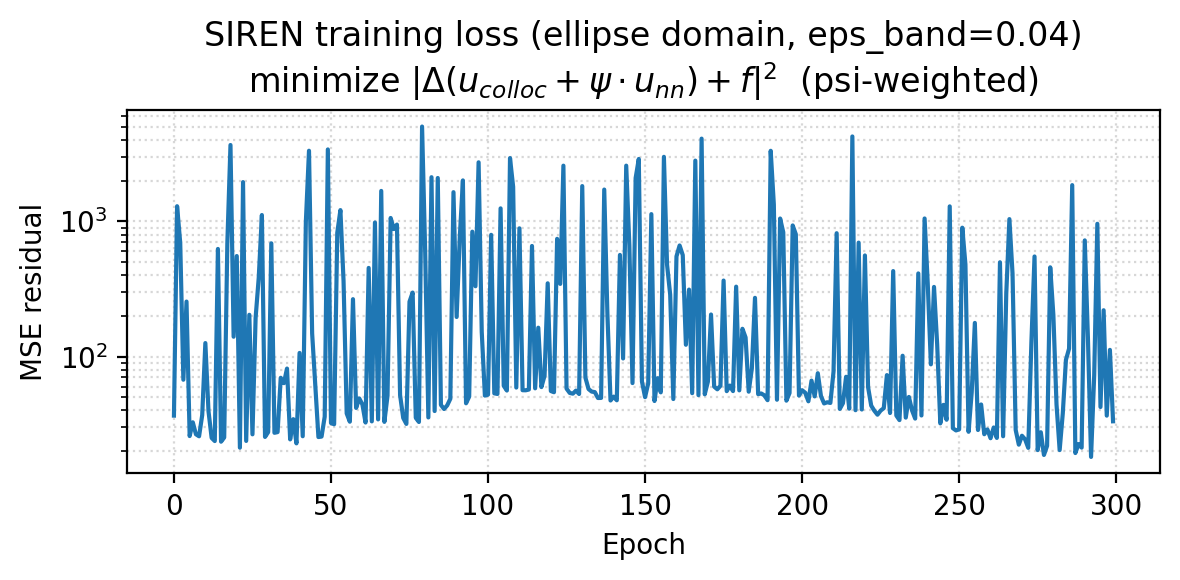

In [50]:
# ==========================================================================
# SIREN TRAINING LOOP (psi-weighted correction, ellipse domain)
# ==========================================================================
# Loss: mean( w_i * |colloc_residual + Laplacian(psi * u_nn)|^2 )

loss_history = []
rng_train = np.random.default_rng(123)

for epoch in range(NUM_EPOCHS):
    idx = rng_train.choice(POOL_SIZE, size=BATCH_SIZE, replace=False)

    bx, by = pool_x[idx], pool_y[idx]
    b_colloc_res = pool_colloc_residual[idx]
    colloc_residual_t = torch.tensor(b_colloc_res, dtype=torch.float64)

    # ---- Neural network (live autograd tensors) ----
    crd = torch.tensor(np.stack([bx, by], axis=-1), dtype=torch.float64,
                       requires_grad=True)
    # Input: algebraic distances from each ellipse
    dists = compute_ellipse_distances_torch(crd, model_corr)
    u_nn = model_nn(dists).squeeze() * DOWNSCALE

    # First derivatives
    grad_u_nn = torch.autograd.grad(
        u_nn, crd, grad_outputs=torch.ones_like(u_nn),
        create_graph=True, retain_graph=True)[0]
    u_nn_x = grad_u_nn[:, 0]
    u_nn_y = grad_u_nn[:, 1]

    # Second derivatives
    u_nn_xx = torch.autograd.grad(
        u_nn_x, crd, grad_outputs=torch.ones_like(u_nn_x),
        create_graph=True, retain_graph=True)[0][:, 0]
    u_nn_yy = torch.autograd.grad(
        u_nn_y, crd, grad_outputs=torch.ones_like(u_nn_y),
        create_graph=True, retain_graph=True)[0][:, 1]

    # Laplacian of (psi * u_nn) via product rule
    b_weight = torch.tensor(pool_loss_weight[idx], dtype=torch.float64)
    b_psi = torch.tensor(pool_psi[idx], dtype=torch.float64)
    b_psi_x = torch.tensor(pool_psi_x[idx], dtype=torch.float64)
    b_psi_y = torch.tensor(pool_psi_y[idx], dtype=torch.float64)
    b_psi_xx = torch.tensor(pool_psi_xx[idx], dtype=torch.float64)
    b_psi_yy = torch.tensor(pool_psi_yy[idx], dtype=torch.float64)

    laplacian_psi_unn = (
        (b_psi_xx + b_psi_yy) * u_nn
        + 2.0 * (b_psi_x * u_nn_x + b_psi_y * u_nn_y)
        + b_psi * (u_nn_xx + u_nn_yy)
    )

    total_residual = colloc_residual_t + laplacian_psi_unn
    loss = (total_residual ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    lr_sched.step()

    loss_val = loss.item()
    loss_history.append(loss_val)
    if epoch % 50 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"epoch {epoch:4d}  loss={loss_val:.6e}")

# Plot training loss
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE residual")
ax.set_title(
    f"SIREN training loss (ellipse domain, eps_band={EPS_BAND})\n"
    r"minimize $|\Delta(u_{colloc} + \psi \cdot u_{nn}) + f|^2$  (psi-weighted)"
)
ax.grid(True, which="both", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()

Sweep config: geom=ellipse pentagon (algebraic dist, R-function)  n=2  H=32
Near-boundary sampling: eps_band=0.04
Psi weighting active (SDF < EPS_BAND): 1546 / 5000

Collocation only:      err_max=1.045e-03  err_mean=4.771e-05
Colloc + u_nn:         err_max=2.345e-03   err_mean=2.770e-04
Improvement:           max err 0.4x  mean err 0.2x


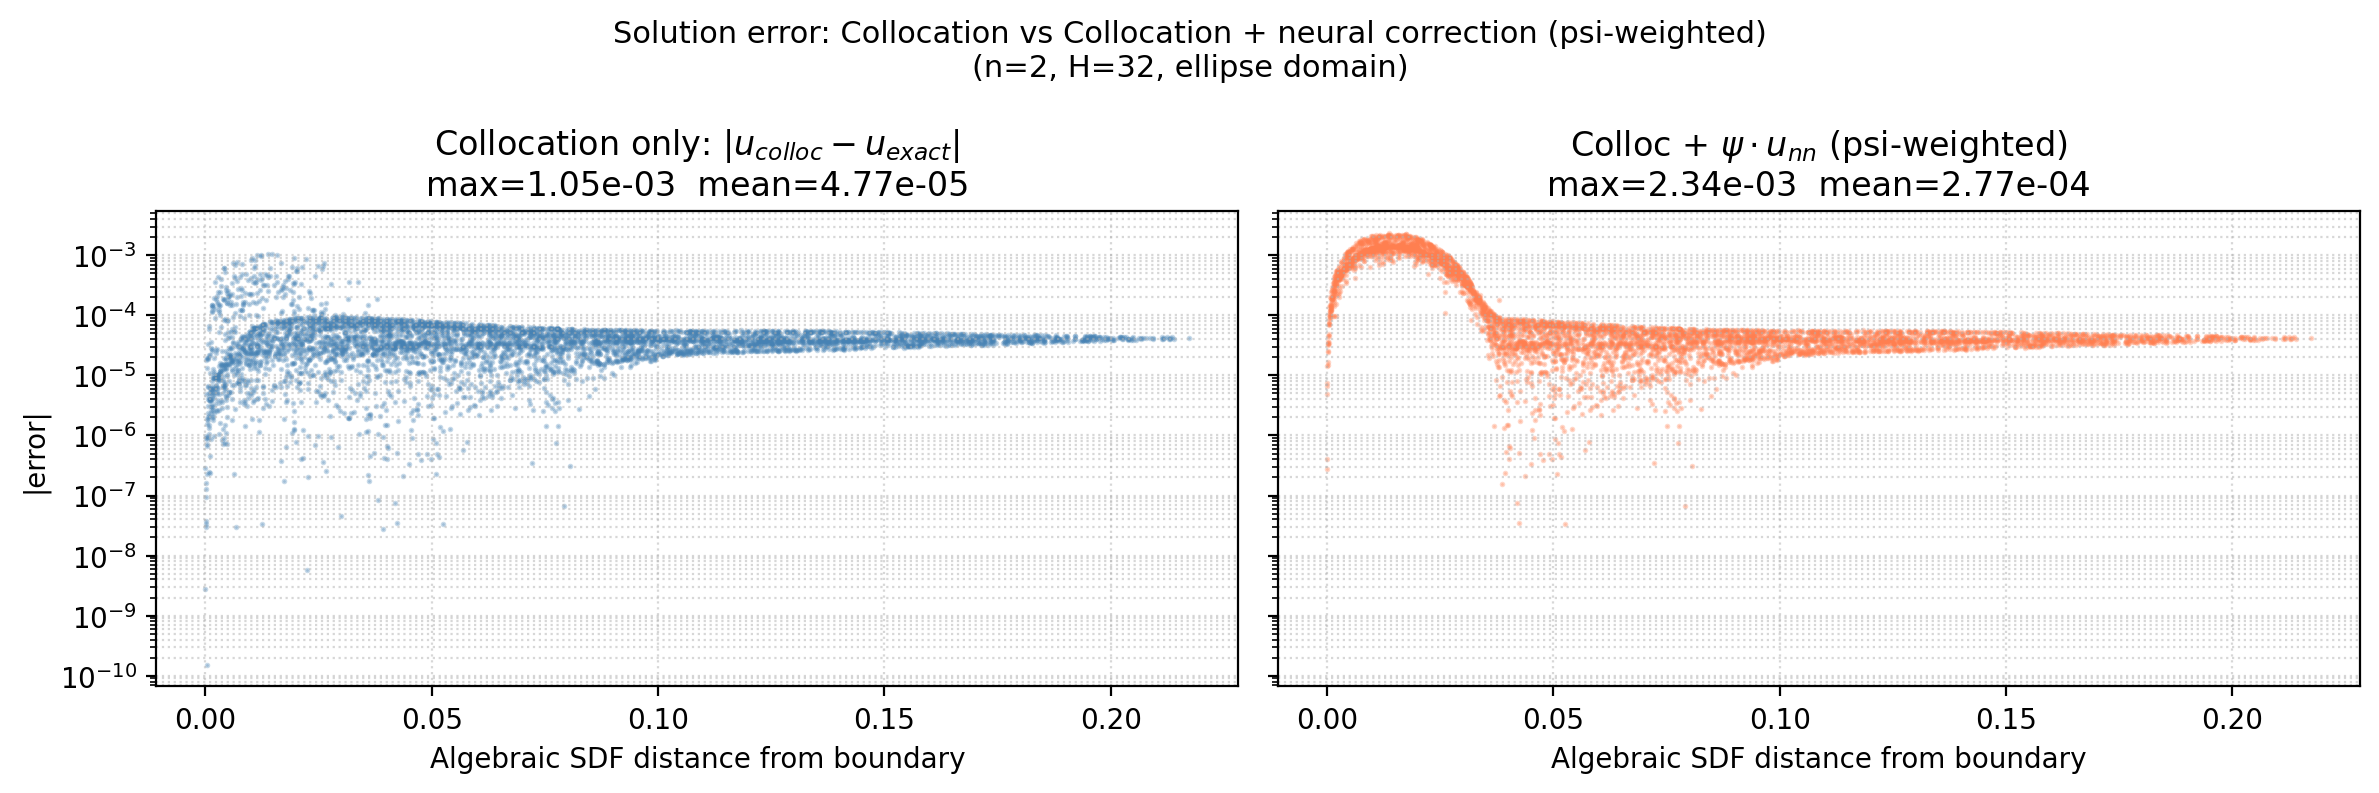

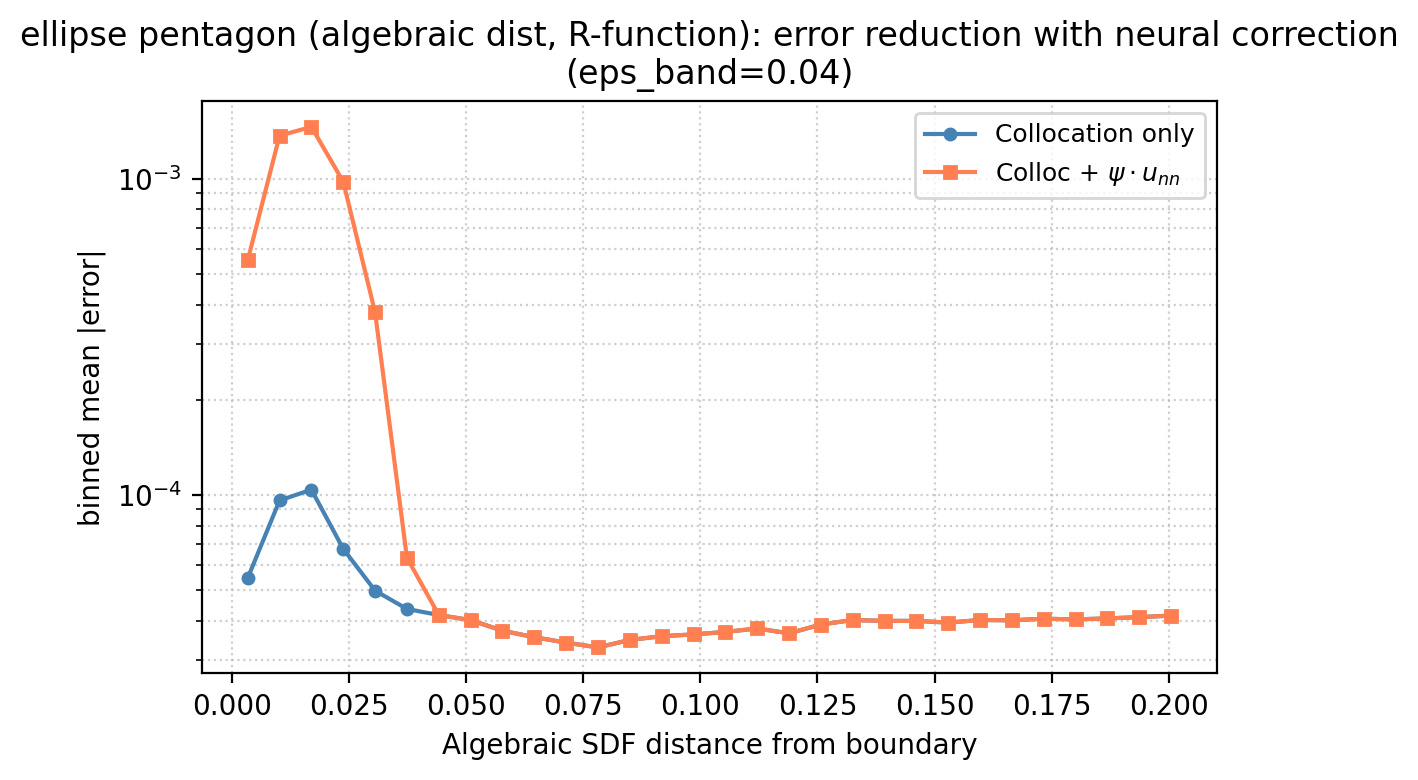

C:\Users\csapo\AppData\Local\Temp\ipykernel_20576\513397678.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf.collections:


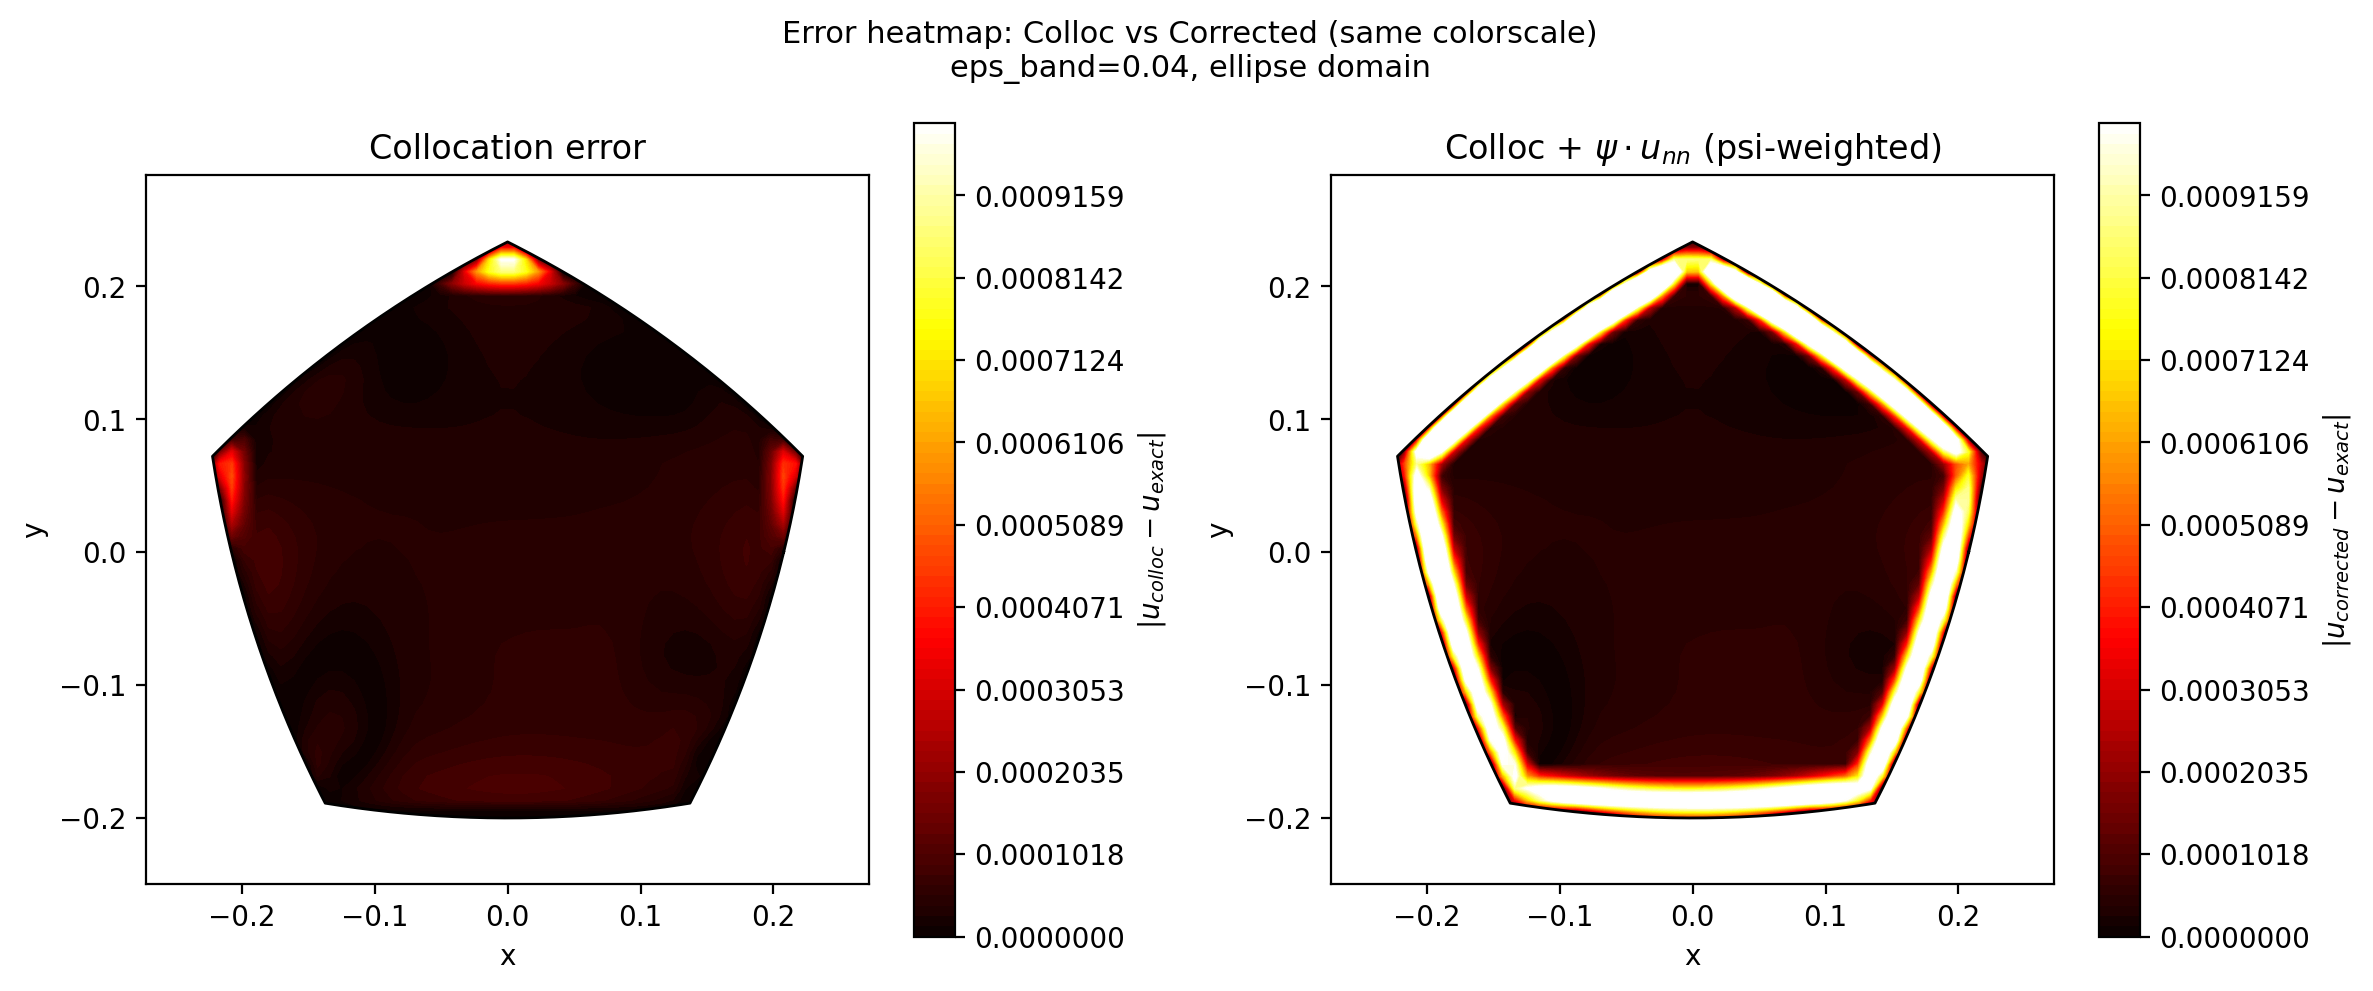

In [48]:
# ==========================================================================
# EVALUATION: Solution error — Collocation vs Collocation + SIREN correction
# ==========================================================================
# u_corrected = u_colloc + psi * u_nn

N_EVAL = 5000

# Sample random interior points for evaluation (different seed from training)
def _sample_interior_ellipse(model, n_pts):
    rng = np.random.default_rng(77)
    bp = model._boundary_pts
    xmin, xmax = float(bp[:, 0].min()) - 0.05, float(bp[:, 0].max()) + 0.05
    ymin, ymax = float(bp[:, 1].min()) - 0.05, float(bp[:, 1].max()) + 0.05
    pts_x, pts_y = [], []
    while len(pts_x) < n_pts:
        batch = max(n_pts * 3, 5000)
        rx = rng.uniform(xmin, xmax, size=batch)
        ry = rng.uniform(ymin, ymax, size=batch)
        inside_mask = point_in_ellipse_domain(rx, ry, model)
        pts_x.append(rx[inside_mask])
        pts_y.append(ry[inside_mask])
    return np.concatenate(pts_x)[:n_pts], np.concatenate(pts_y)[:n_pts]

pts_x_plot, pts_y_plot = _sample_interior_ellipse(model_corr, N_EVAL)

# ---- Collocation solution at evaluation points (B-spline basis) ----
u_h = colloc.reconstruct_collocation_at_points(
    pts_x_plot, pts_y_plot, recon_info_corr, wfct_phys_corr)

# ---- Exact solution ----
u_ex = u_exact_phys_corr(pts_x_plot, pts_y_plot)

# ---- Algebraic SDF for band mask and plotting ----
sdf_plot = model_corr.min_algebraic_distance_numpy(pts_x_plot, pts_y_plot)

# ---- Compute psi weighting at evaluation points ----
psi_eval, _, _, _, _ = compute_psi_all_ellipse(
    pts_x_plot, pts_y_plot, model_corr, wfct_phys_corr, EPS_BAND)

# ---- Neural network correction at evaluation points ----
crd_plot = torch.tensor(np.stack([pts_x_plot, pts_y_plot], axis=-1), dtype=torch.float64)
dists_plot = compute_ellipse_distances_torch(crd_plot, model_corr)
with torch.no_grad():
    u_nn_eval = model_nn(dists_plot).squeeze().numpy()
u_nn_eval = u_nn_eval * DOWNSCALE

# Corrected solution: u = u_colloc + psi * u_nn
u_corrected = u_h + psi_eval * u_nn_eval

# ---- Errors ----
err_before = np.abs(u_h - u_ex)
err_after = np.abs(u_corrected - u_ex)

s_corr = res_corr["summary"]
print(f"Sweep config: geom={s_corr['geom']}  n={s_corr['n']}  H={s_corr['H']}")
print(f"Near-boundary sampling: eps_band={EPS_BAND}")
print(f"Psi weighting active (SDF < EPS_BAND): {(psi_eval > 0).sum()} / {len(psi_eval)}")
print(f"\nCollocation only:      err_max={err_before.max():.3e}  err_mean={err_before.mean():.3e}")
print(f"Colloc + u_nn:         err_max={err_after.max():.3e}   err_mean={err_after.mean():.3e}")
print(f"Improvement:           max err {err_before.max()/max(err_after.max(), 1e-30):.1f}x  "
      f"mean err {err_before.mean()/max(err_after.mean(), 1e-30):.1f}x")

valid = sdf_plot > 0

# ---- Binned error comparison ----
bins_before = compute_near_boundary_binning(w_inside=sdf_plot, err_inside=err_before, n_bins=30)
bins_after = compute_near_boundary_binning(w_inside=sdf_plot, err_inside=err_after, n_bins=30)

# ---- Plot 1: Scatter — error vs SDF before and after ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax1.scatter(sdf_plot[valid], err_before[valid], s=1, alpha=0.3, c="steelblue", rasterized=True)
ax1.set_yscale("log")
ax1.set_xlabel("Algebraic SDF distance from boundary")
ax1.set_ylabel("|error|")
ax1.set_title(f"Collocation only: |$u_{{colloc}} - u_{{exact}}$|\n"
              f"max={err_before.max():.2e}  mean={err_before.mean():.2e}")
ax1.grid(True, which="both", ls=":", alpha=0.5)

ax2.scatter(sdf_plot[valid], err_after[valid], s=1, alpha=0.3, c="coral", rasterized=True)
ax2.set_yscale("log")
ax2.set_xlabel("Algebraic SDF distance from boundary")
ax2.set_title(f"Colloc + $\\psi \\cdot u_{{nn}}$ (psi-weighted)\n"
              f"max={err_after.max():.2e}  mean={err_after.mean():.2e}")
ax2.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(f"Solution error: Collocation vs Collocation + neural correction (psi-weighted)\n"
             f"(n={s_corr['n']}, H={s_corr['H']}, ellipse domain)",
             fontsize=11)
fig.tight_layout()
plt.show()

# ---- Plot 2: Binned error comparison ----
fig, ax = plt.subplots(figsize=(6, 4))
if not bins_before.empty:
    ax.plot(bins_before["w_mid"], bins_before["err_mean"], marker="o", ms=4, lw=1.5,
            label="Collocation only", color="steelblue")
if not bins_after.empty:
    ax.plot(bins_after["w_mid"], bins_after["err_mean"], marker="s", ms=4, lw=1.5,
            label=r"Colloc + $\psi \cdot u_{nn}$", color="coral")
ax.set_yscale("log")
ax.set_xlabel("Algebraic SDF distance from boundary")
ax.set_ylabel("binned mean |error|")
ax.set_title(f"{CORR_GEOM_NAME}: error reduction with neural correction\n"
             f"(eps_band={EPS_BAND})")
ax.legend(fontsize=9)
ax.grid(True, which="both", ls=":", alpha=0.6)
fig.tight_layout()
plt.show()

# ---- Plot 3: Spatial error heatmap before/after ----
boundary_pts_corr = model_corr._boundary_pts
bp = boundary_pts_corr
xmin_v, xmax_v = float(bp[:, 0].min()) - 0.05, float(bp[:, 0].max()) + 0.05
ymin_v, ymax_v = float(bp[:, 1].min()) - 0.05, float(bp[:, 1].max()) + 0.05
HN = 60
hm_x = np.linspace(xmin_v, xmax_v, HN)
hm_y = np.linspace(ymin_v, ymax_v, HN)
HX, HY = np.meshgrid(hm_x, hm_y)

# Evaluate on heatmap grid using B-spline basis
hm_flat_x = HX.ravel()
hm_flat_y = HY.ravel()
hm_u_colloc = colloc.reconstruct_collocation_at_points(
    hm_flat_x, hm_flat_y, recon_info_corr, wfct_phys_corr)
hm_u_ex = u_exact_phys_corr(hm_flat_x, hm_flat_y)

# Weight for masking
hm_w, *_ = wfct_phys_corr(hm_flat_x, hm_flat_y)
hm_w = np.asarray(hm_w).ravel()
hm_inside = hm_w > 0

# Compute psi weighting on heatmap grid
hm_psi, _, _, _, _ = compute_psi_all_ellipse(
    hm_flat_x, hm_flat_y, model_corr, wfct_phys_corr, EPS_BAND)

# Neural correction on heatmap grid
hm_crd = torch.tensor(np.stack([hm_flat_x, hm_flat_y], axis=-1), dtype=torch.float64)
hm_dists = compute_ellipse_distances_torch(hm_crd, model_corr)
with torch.no_grad():
    hm_u_nn = model_nn(hm_dists).squeeze().numpy() * DOWNSCALE

# Apply psi-weighted correction
hm_u_corr = hm_u_colloc + hm_psi * hm_u_nn

err_colloc_grid = np.abs(hm_u_colloc - hm_u_ex).reshape(HX.shape)
err_corr_grid = np.abs(hm_u_corr - hm_u_ex).reshape(HX.shape)
valid_grid = hm_inside.reshape(HX.shape)

# Set outside values to 0 for smooth contourf boundary
err_colloc_plot = err_colloc_grid.copy()
err_colloc_plot[~valid_grid] = 0.0
err_corr_plot = err_corr_grid.copy()
err_corr_plot[~valid_grid] = 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(err_colloc_grid[valid_grid]) if np.any(valid_grid) else 1e-6
levels_hm = np.linspace(0, vmax, 80)

im1 = ax1.contourf(HX, HY, err_colloc_plot, levels=levels_hm, cmap="hot")
_clip_contourf_to_boundary(im1, ax1, boundary_pts_corr)
fig.colorbar(im1, ax=ax1, label=r"$|u_{colloc} - u_{exact}|$")
ax1.set_title("Collocation error")
ax1.set_aspect("equal")

im2 = ax2.contourf(HX, HY, err_corr_plot, levels=levels_hm, cmap="hot")
_clip_contourf_to_boundary(im2, ax2, boundary_pts_corr)
fig.colorbar(im2, ax=ax2, label=r"$|u_{corrected} - u_{exact}|$")
ax2.set_title(f"Colloc + $\\psi \\cdot u_{{nn}}$ (psi-weighted)")
ax2.set_aspect("equal")

# Draw boundary on both
for ax in [ax1, ax2]:
    ax.plot(np.append(bp[:, 0], bp[0, 0]),
            np.append(bp[:, 1], bp[0, 1]),
            'k-', linewidth=1.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle(f"Error heatmap: Colloc vs Corrected (same colorscale)\n"
             f"eps_band={EPS_BAND}, ellipse domain", fontsize=11)
fig.tight_layout()
plt.show()

Derivative errors: ellipse pentagon (algebraic dist, R-function) | n=2 H=32
DOWNSCALE=1.0, correction=PSI WEIGHTING (ellipse domain)

 Deriv    Colloc max    Correc max   Improvement
   u_x     1.082e-01     1.503e-01           0.7x
   u_y     1.439e-01     1.711e-01           0.8x
  u_xx     2.212e+01     2.835e+01           0.8x
  u_yy     2.929e+01     3.909e+01           0.7x

 Deriv   Colloc mean   Correc mean   Improvement
   u_x     1.759e-03     4.751e-03           0.4x
   u_y     1.633e-03     4.668e-03           0.3x
  u_xx     3.010e-01     9.518e-01           0.3x
  u_yy     2.677e-01     9.174e-01           0.3x

      Norm    Colloc max    Correc max   Improvement
|grad err|     1.580e-01     1.874e-01           0.8x
|hess err|     3.350e+01     4.829e+01           0.7x


C:\Users\csapo\AppData\Local\Temp\ipykernel_20576\513397678.py:116: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf.collections:


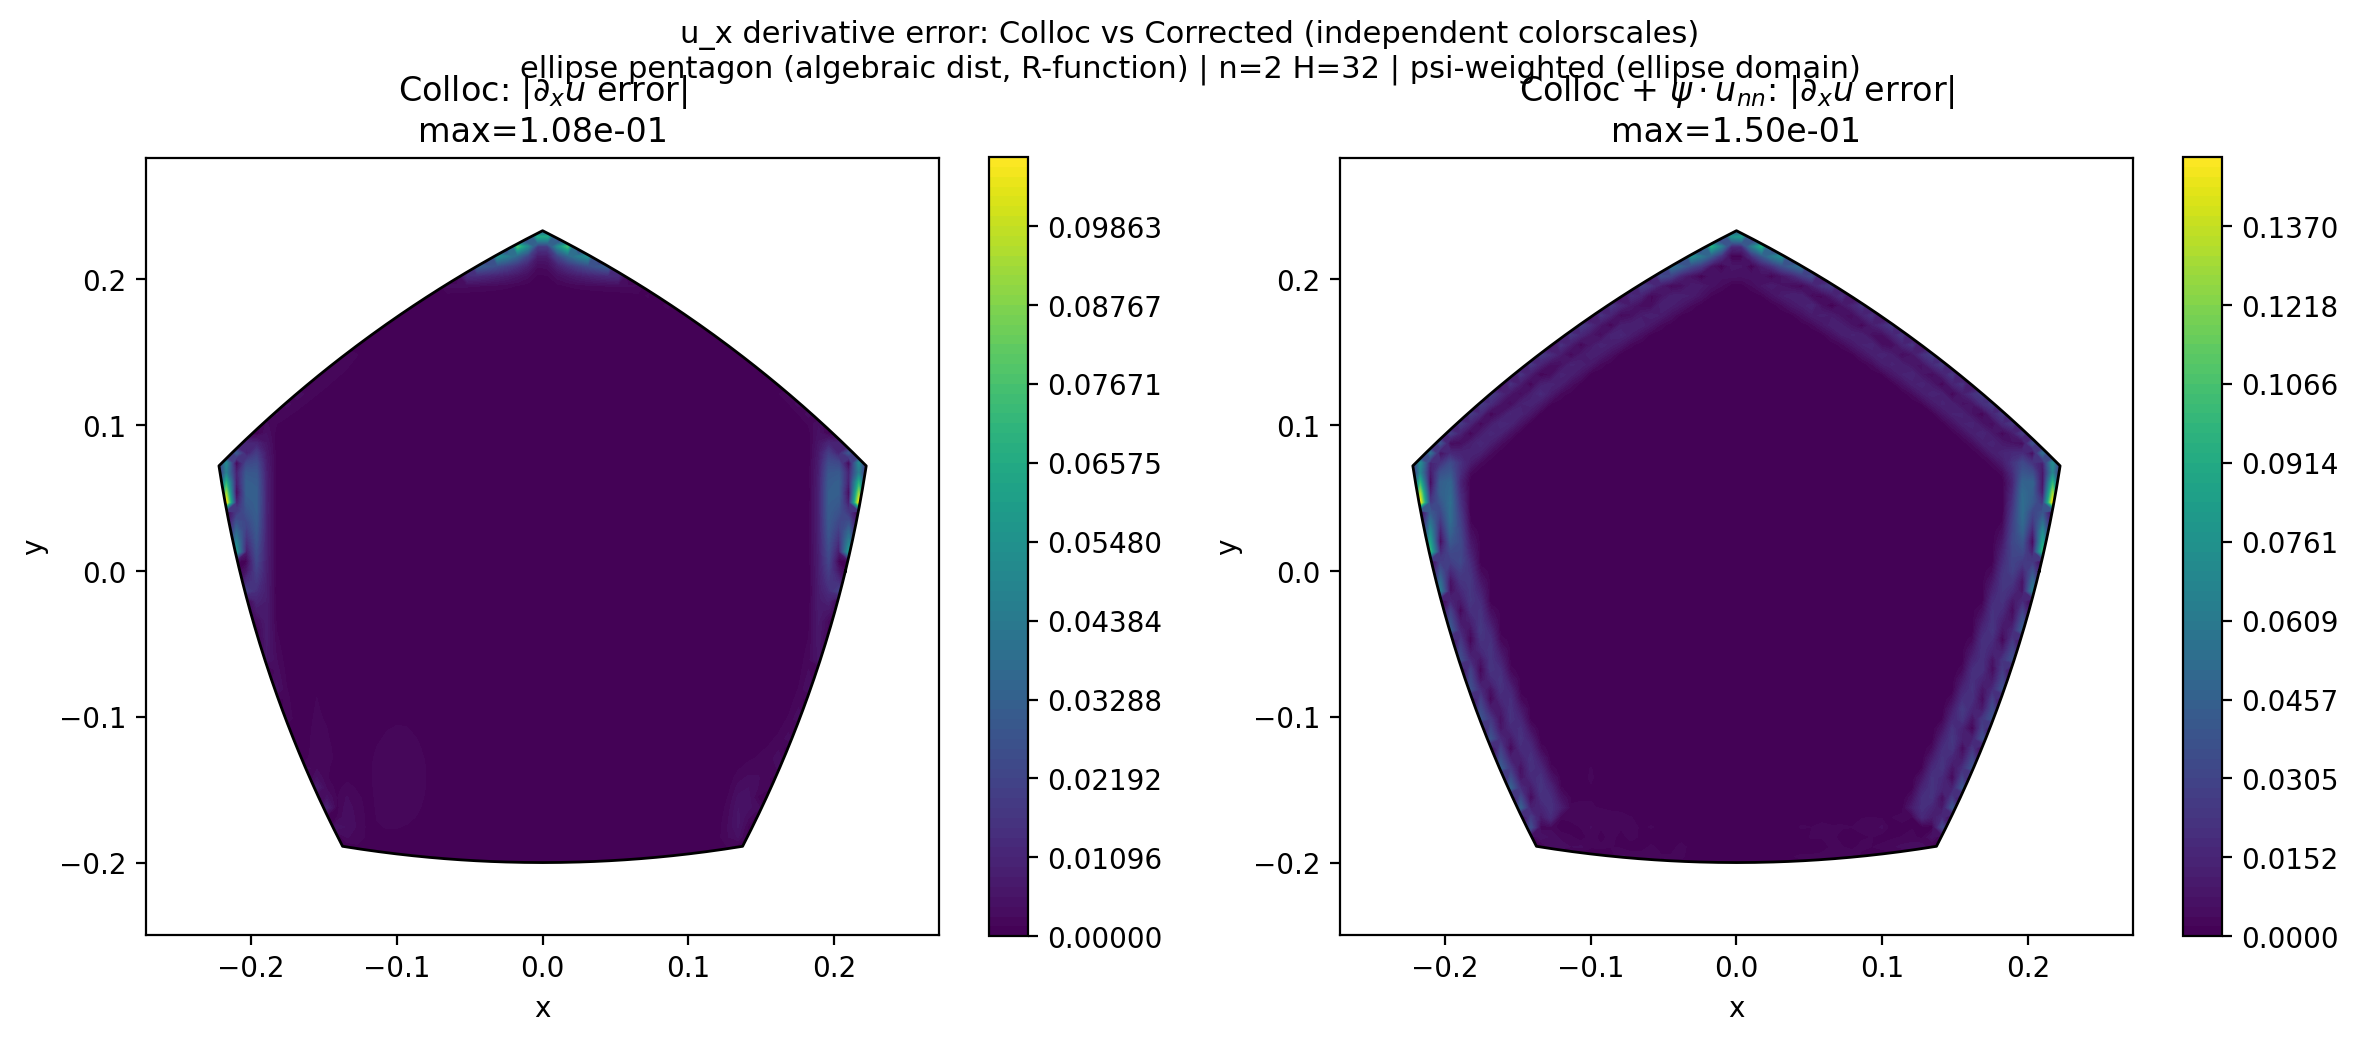

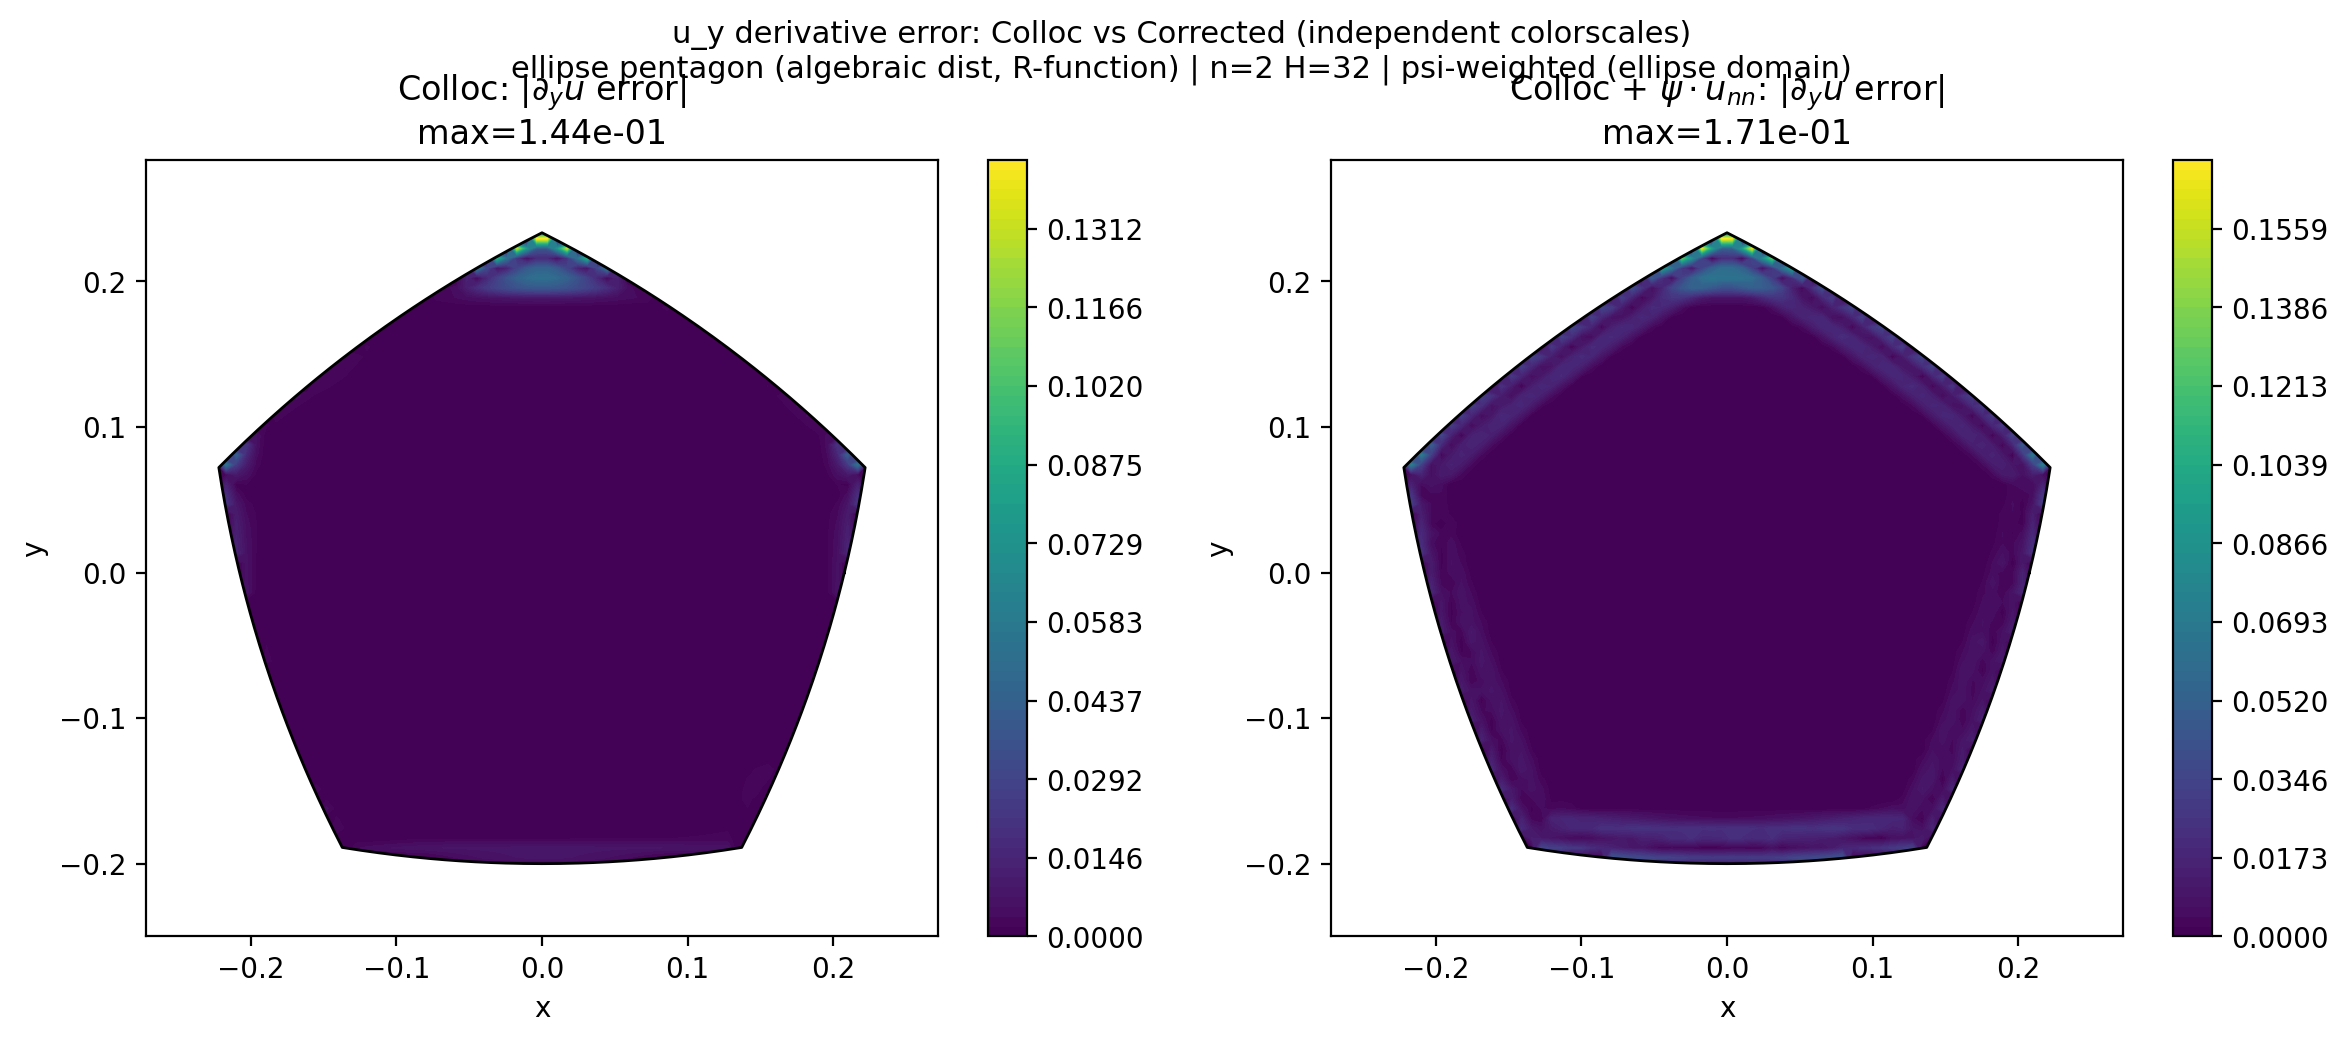

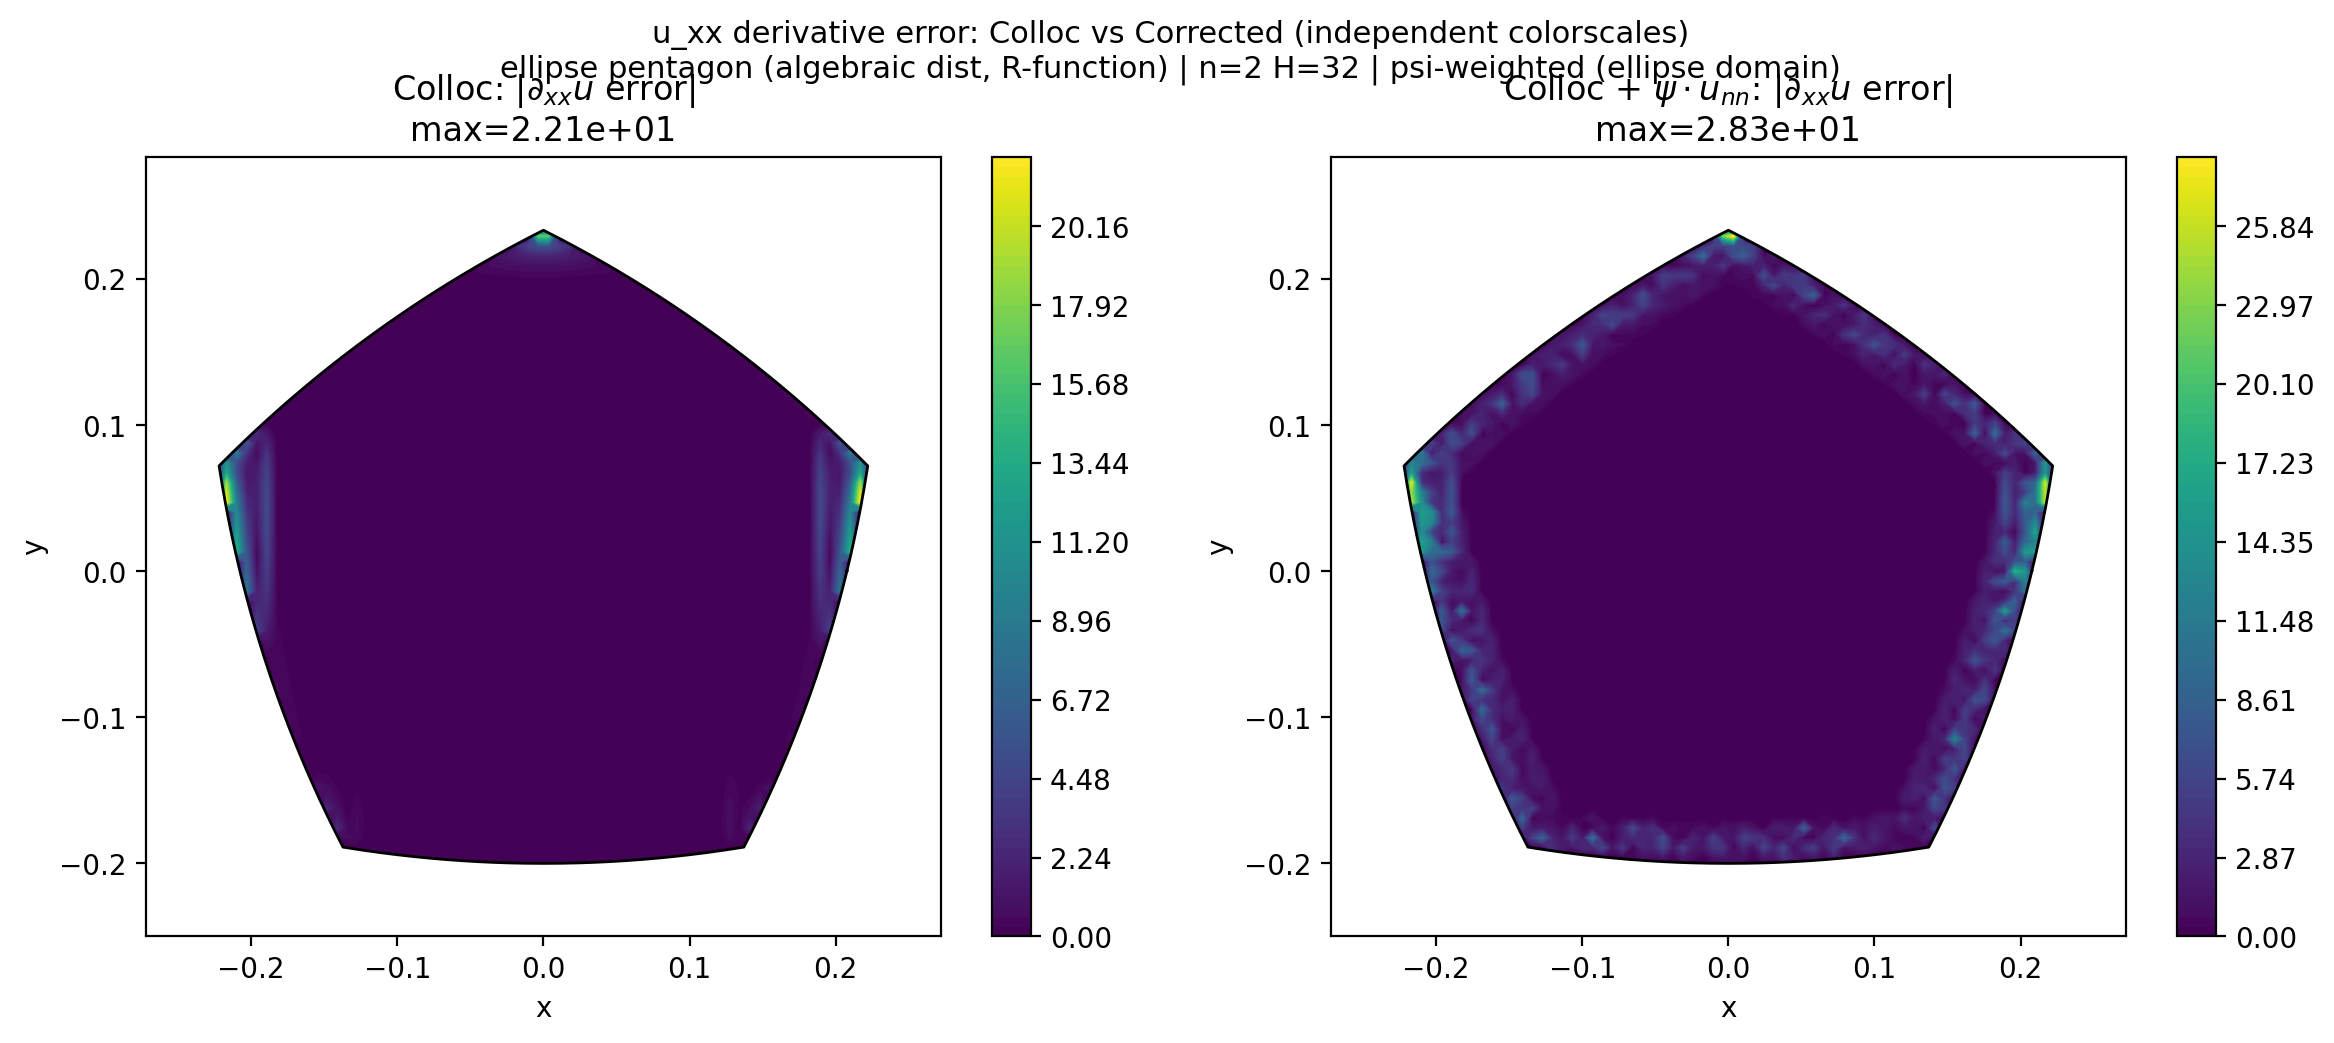

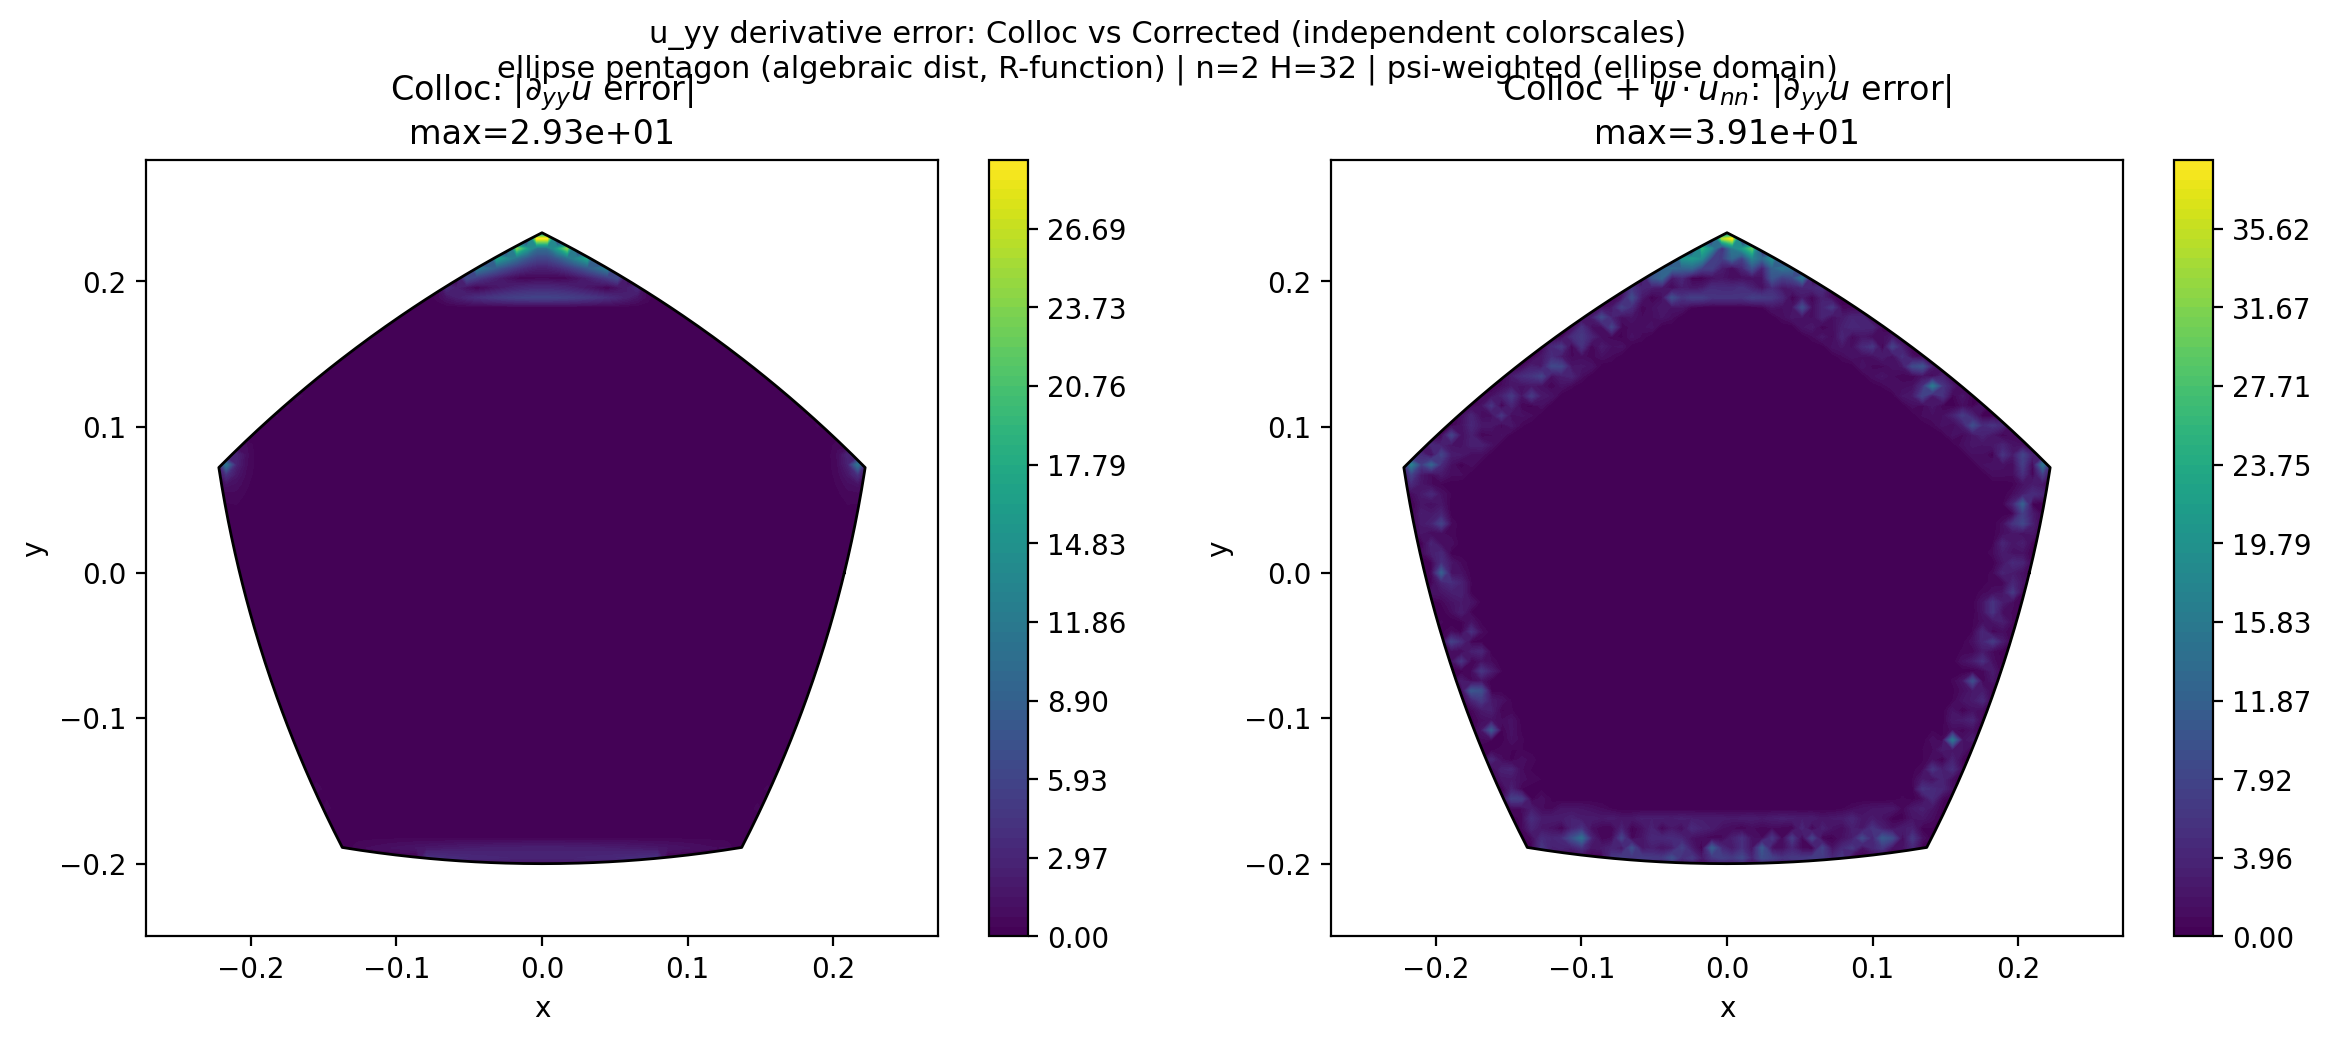

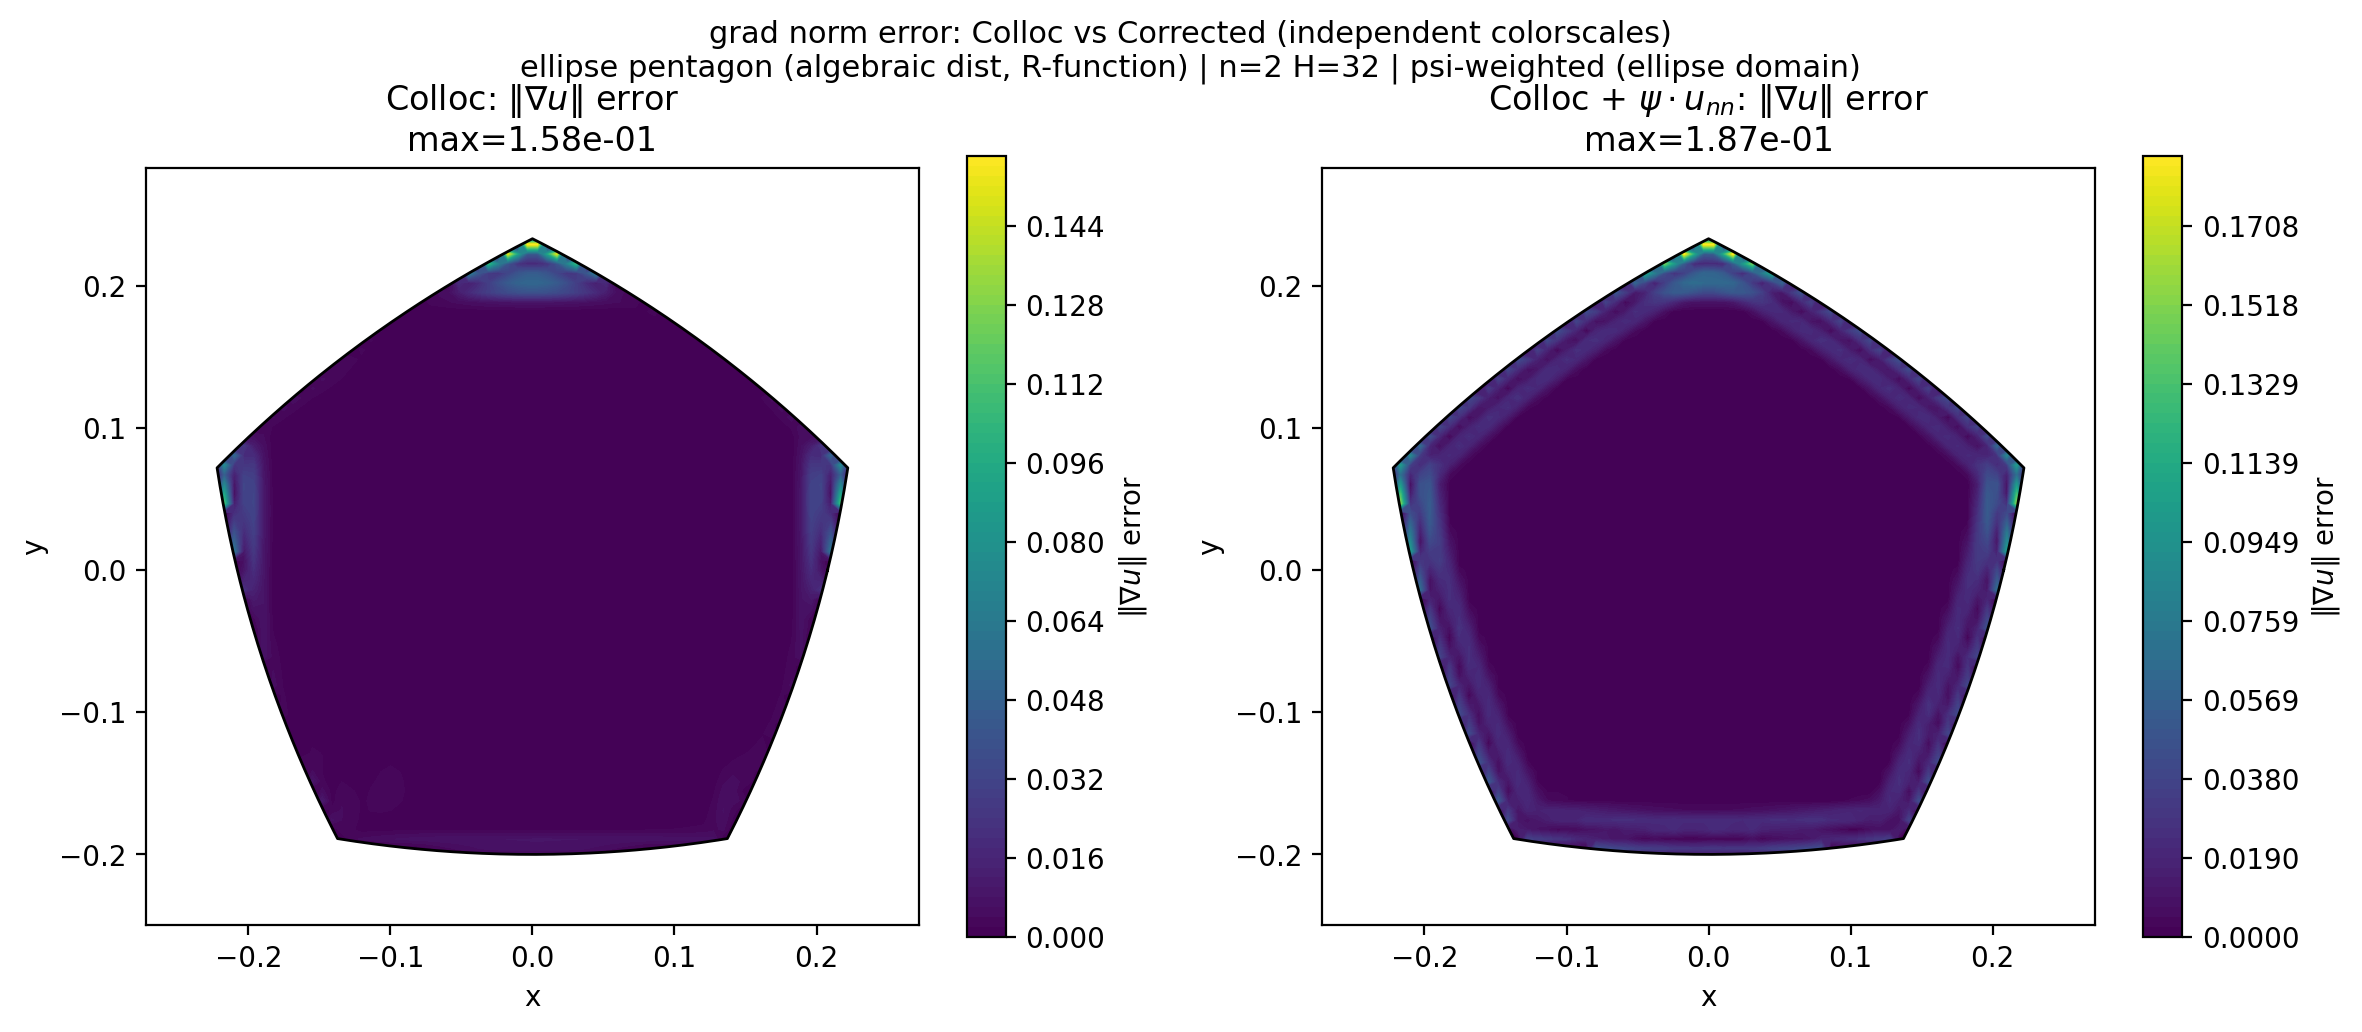

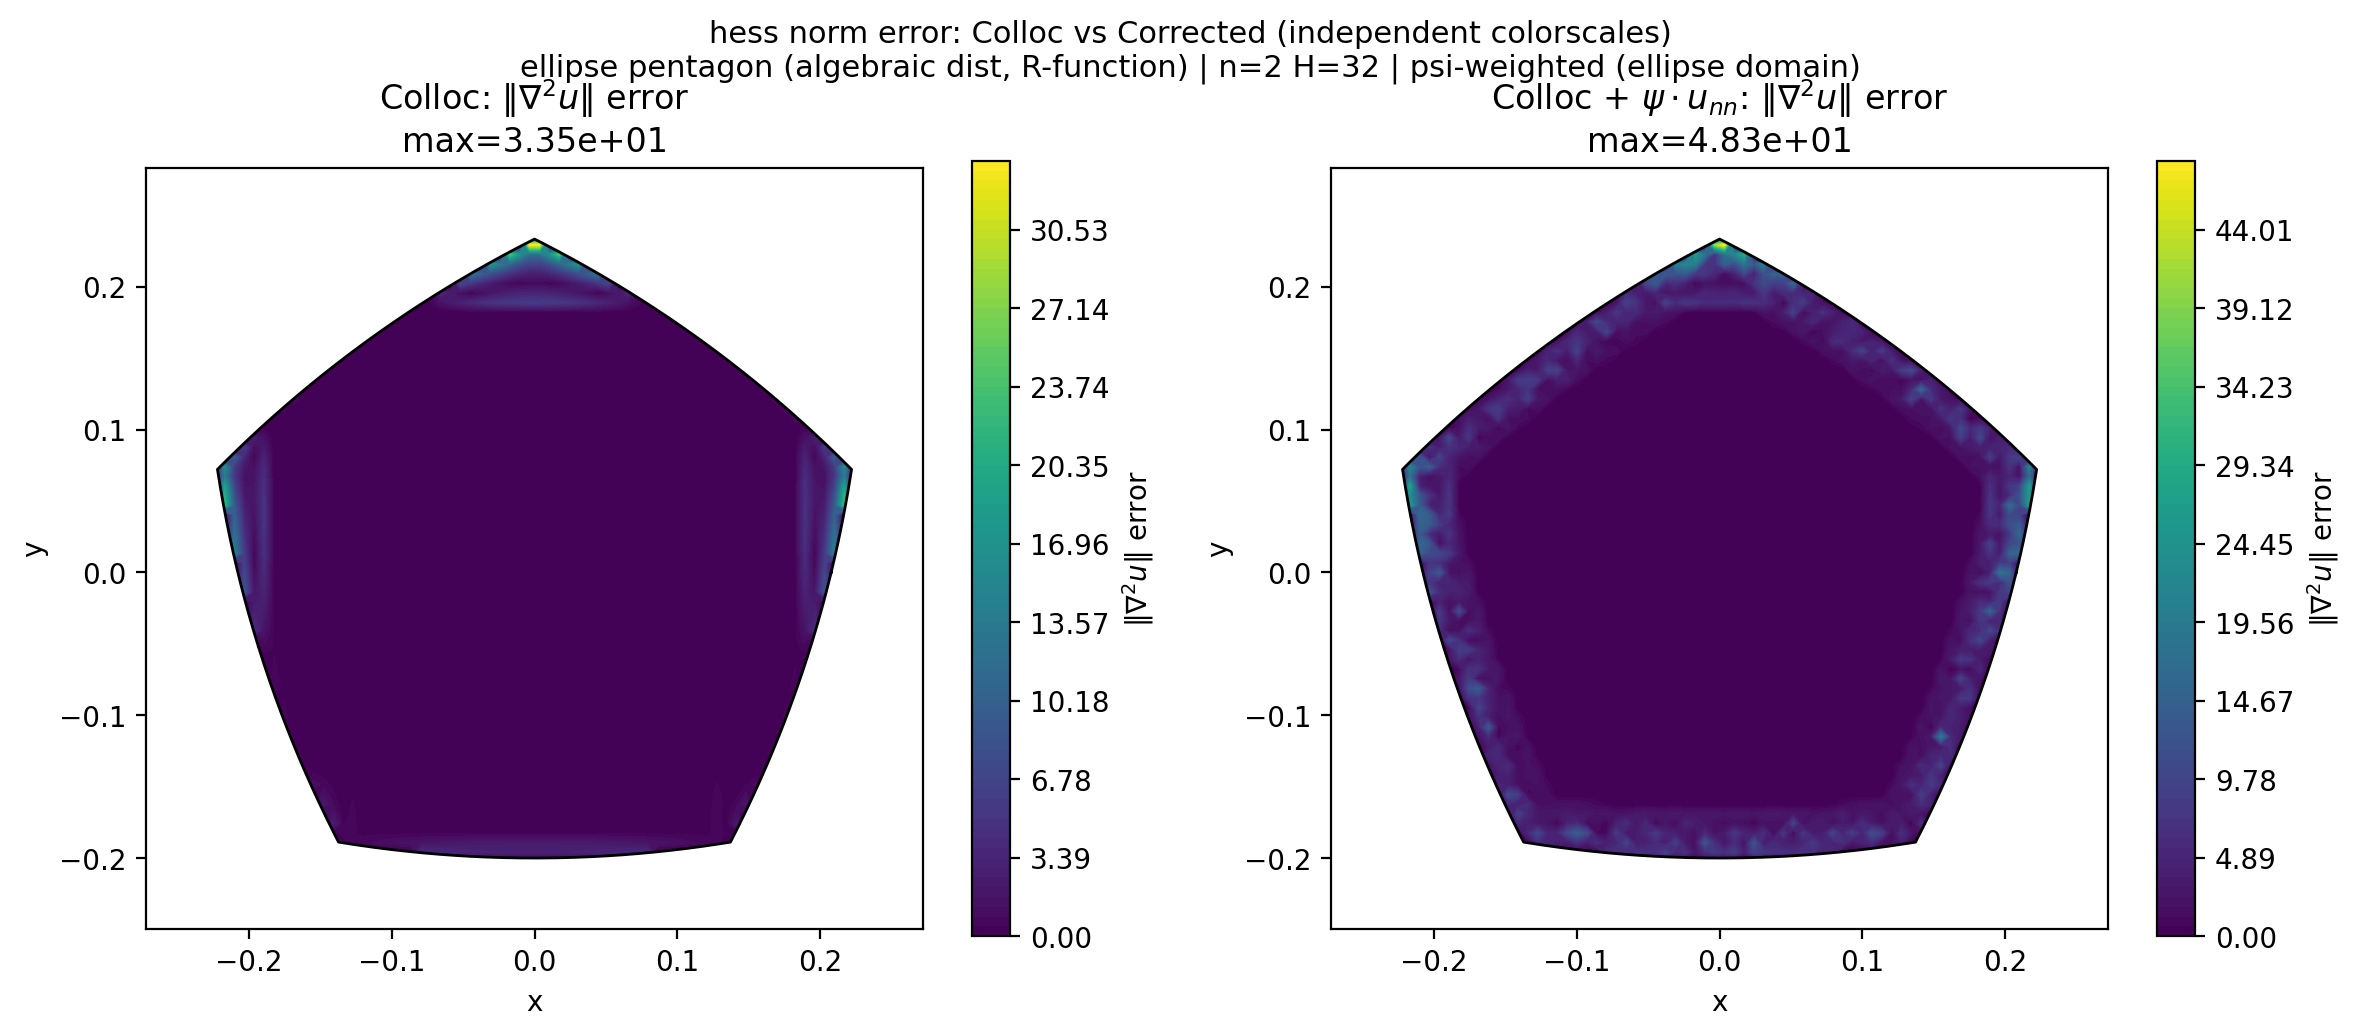

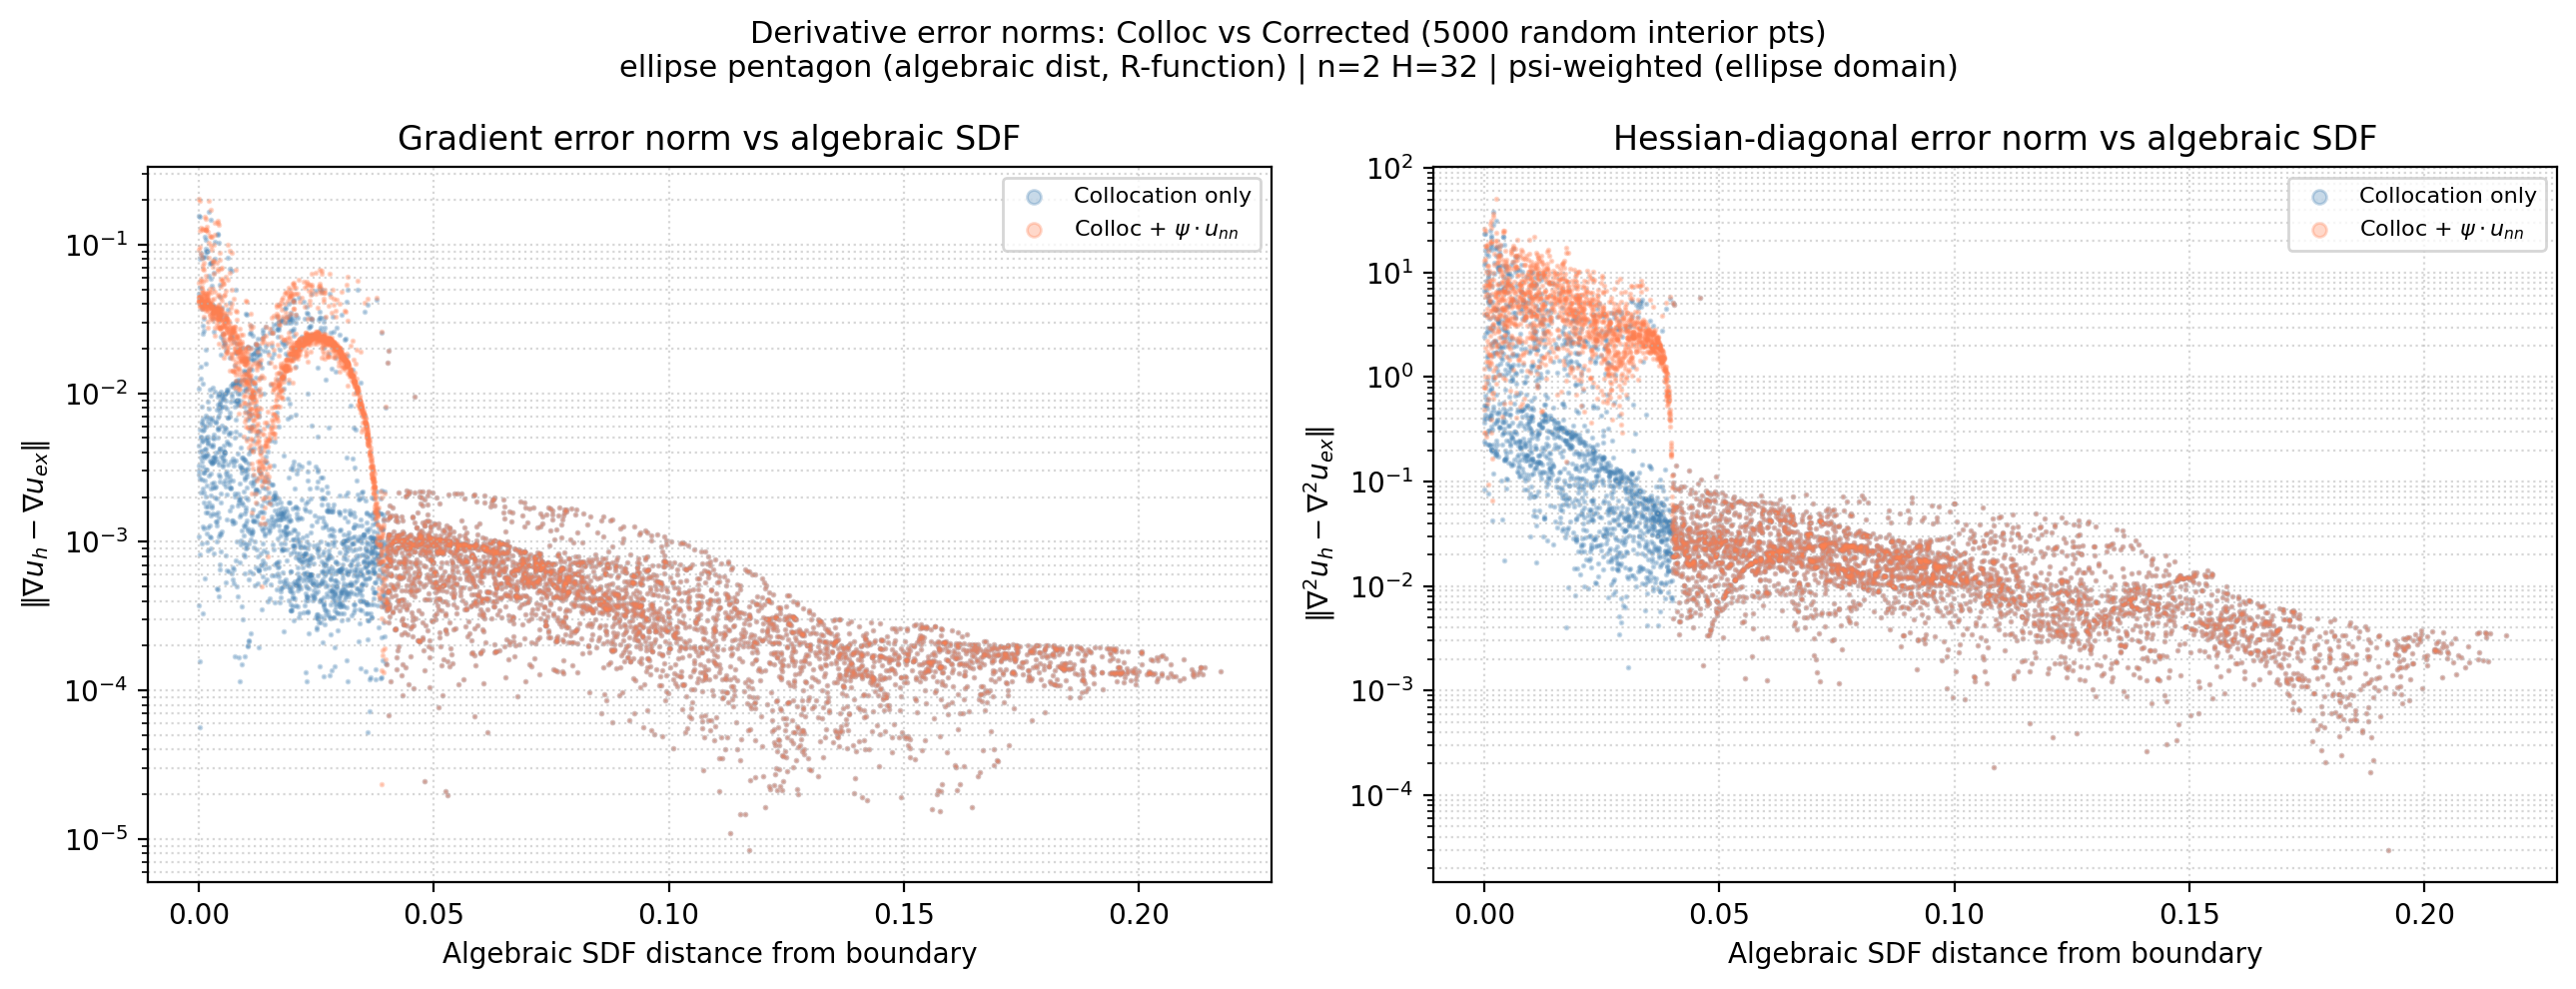

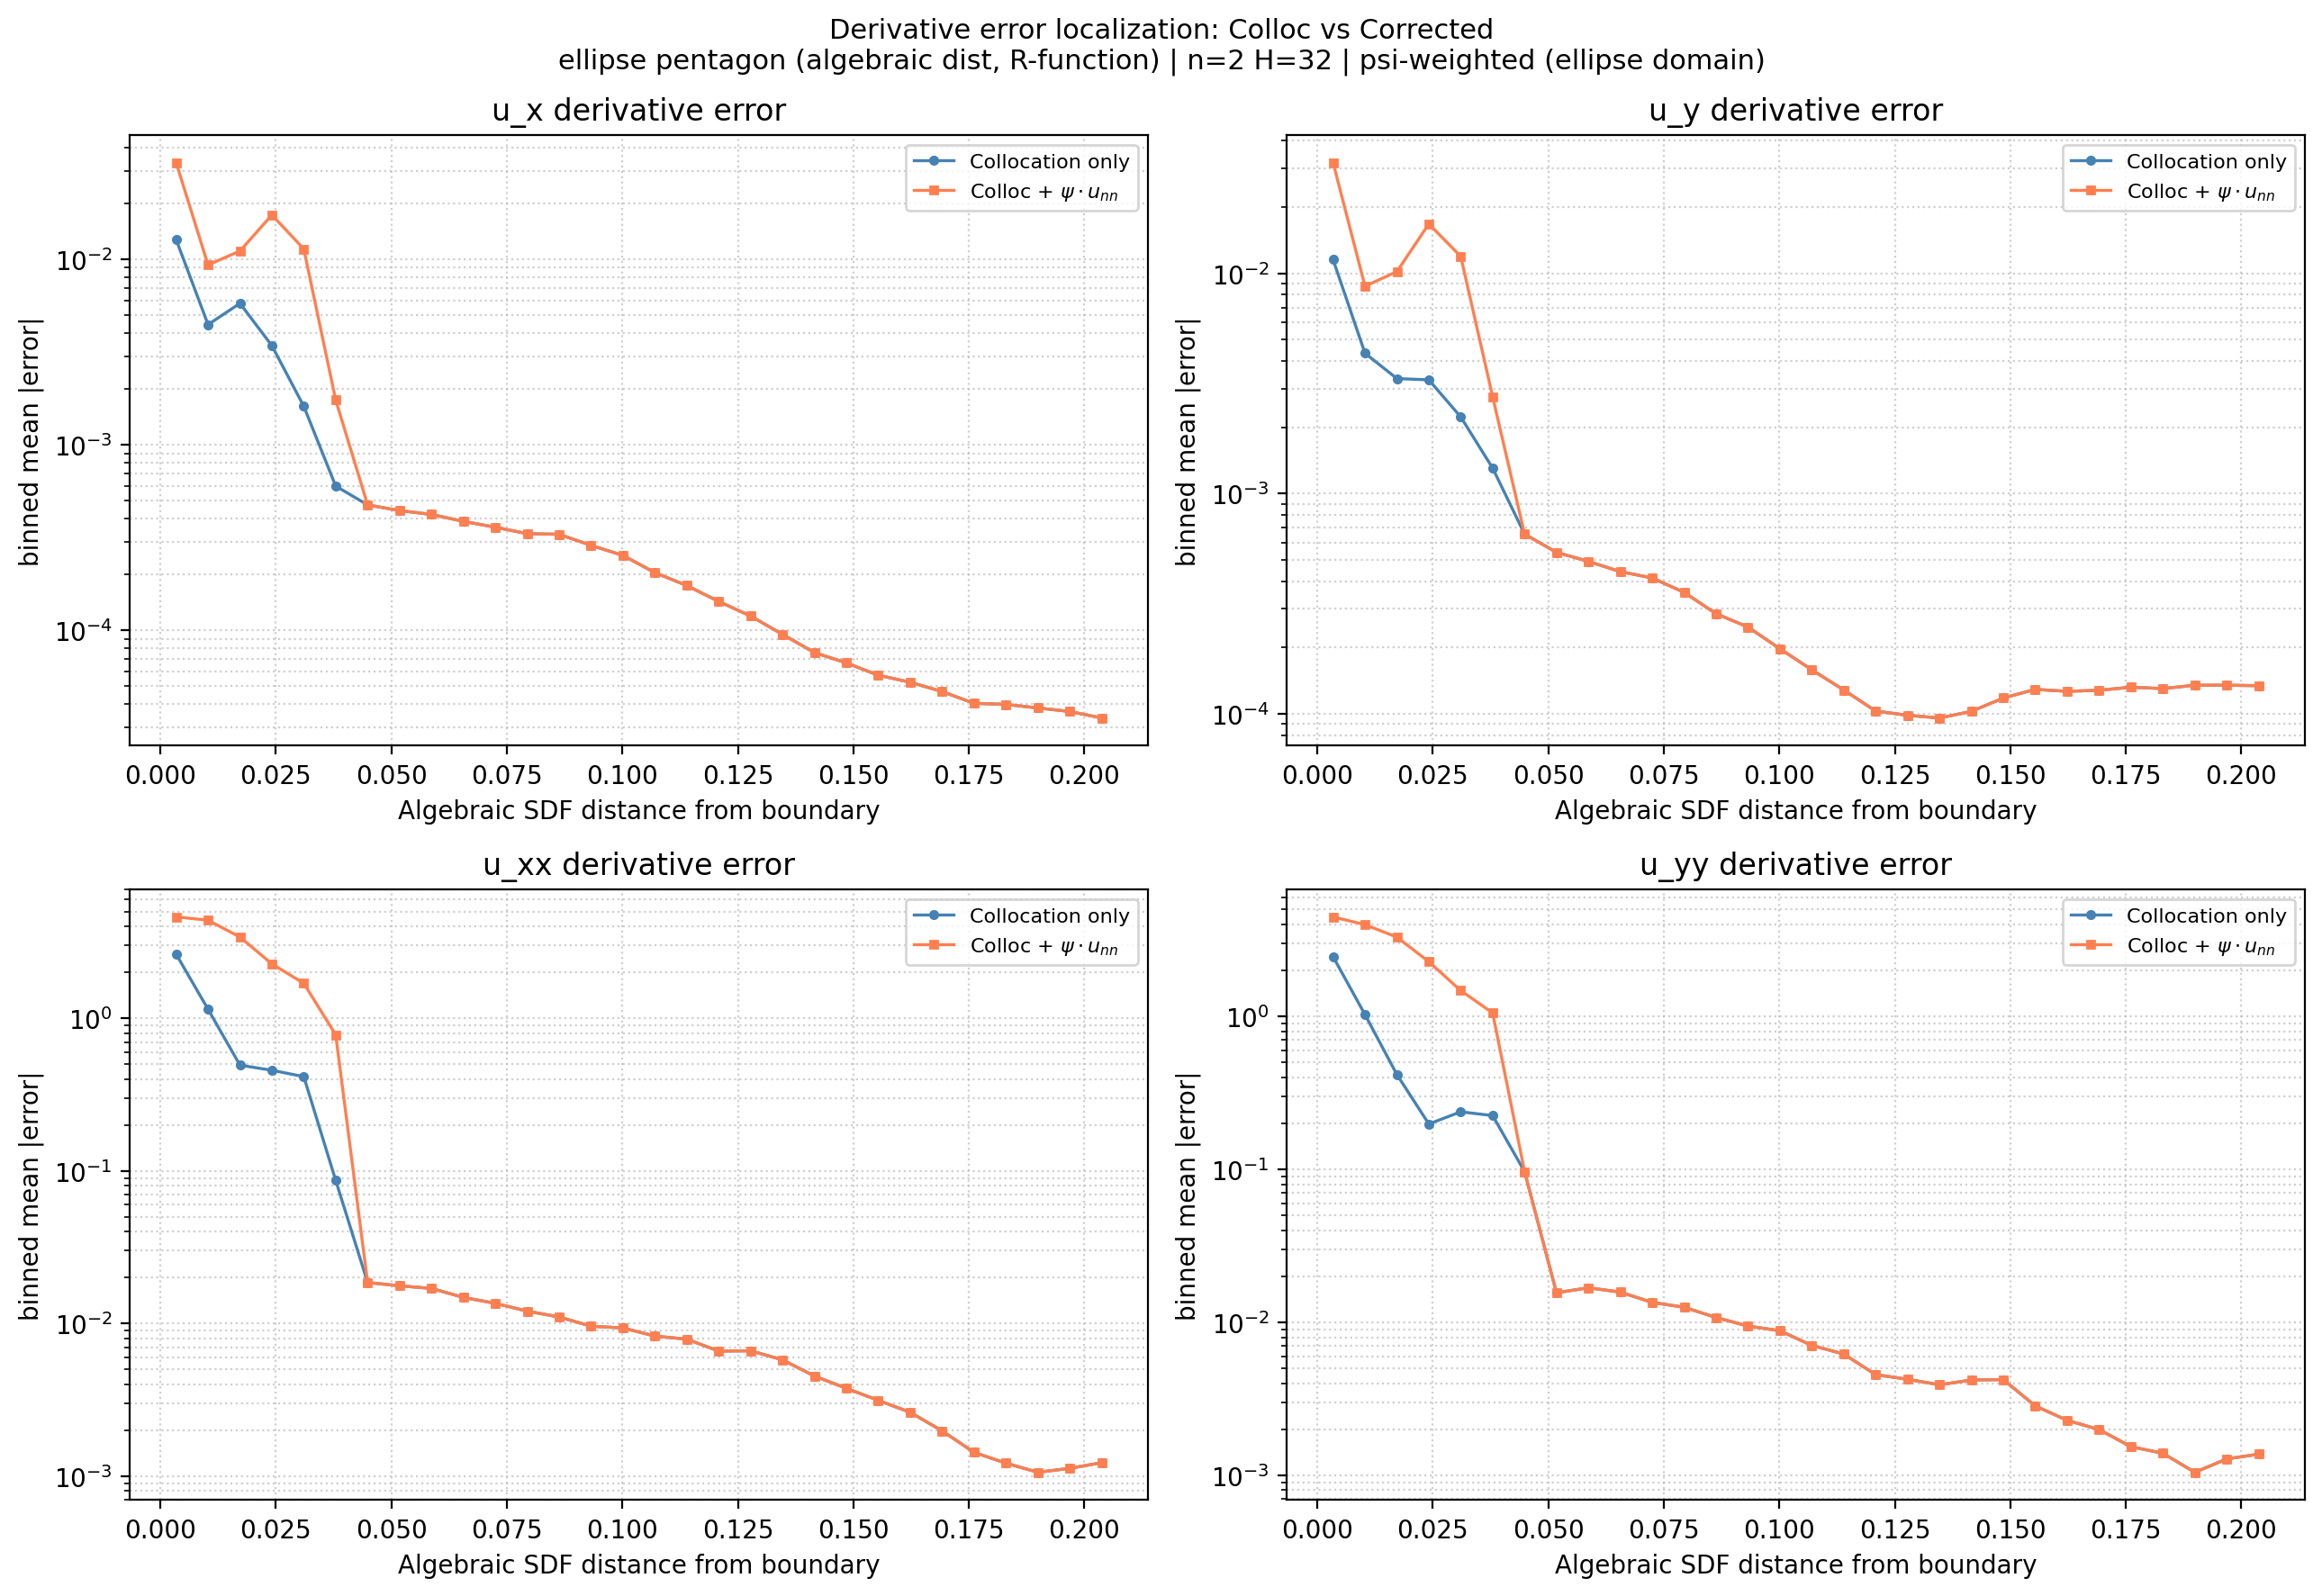

In [45]:
# ==========================================================================
# DERIVATIVE ERROR: Collocation vs Collocation + Neural Correction (ellipse)
# ==========================================================================
# All derivatives are computed analytically (no numeric finite differences):
#   - Collocation: B-spline basis differentiation (reconstruct_collocation_hessian_diag)
#   - Neural network u_nn: PyTorch autograd through algebraic distances
#
# Corrected solution (psi-weighted):
#   u_corr = u_colloc + psi * u_nn
#   (u_corr)_x  = (u_colloc)_x  + psi_x * u_nn + psi * (u_nn)_x
#   (u_corr)_xx = (u_colloc)_xx + psi_xx * u_nn + 2*psi_x*(u_nn)_x + psi*(u_nn)_xx

HN_d = 80
boundary_pts_d = model_corr._boundary_pts
bp_d = boundary_pts_d
xmin_d = float(bp_d[:, 0].min()) - 0.05
xmax_d = float(bp_d[:, 0].max()) + 0.05
ymin_d = float(bp_d[:, 1].min()) - 0.05
ymax_d = float(bp_d[:, 1].max()) + 0.05
gx_d = np.linspace(xmin_d, xmax_d, HN_d)
gy_d = np.linspace(ymin_d, ymax_d, HN_d)
GX_d, GY_d = np.meshgrid(gx_d, gy_d)
flat_xd, flat_yd = GX_d.ravel(), GY_d.ravel()

# --- Step 1: Collocation solution derivatives (analytical via B-spline) ---
u_col, ux_col, uy_col, uxx_col, uyy_col = colloc.reconstruct_collocation_hessian_diag(
    flat_xd, flat_yd, recon_info_corr, wfct_phys_corr)

# --- Step 2: Weight function w (for inside mask) and algebraic SDF ---
w_d, *_ = wfct_phys_corr(flat_xd, flat_yd)
w_d = np.asarray(w_d).ravel()
inside_d = w_d > 0
valid_d = inside_d.reshape(GX_d.shape)

# Algebraic SDF for binning
sdf_d = model_corr.min_algebraic_distance_numpy(flat_xd, flat_yd)
sdf_inside_d = sdf_d[inside_d]

# --- Step 3: Neural network u_nn and its derivatives via PyTorch autograd ---
crd_d = torch.tensor(np.stack([flat_xd, flat_yd], axis=-1), dtype=torch.float64,
                     requires_grad=True)
dists_d = compute_ellipse_distances_torch(crd_d, model_corr)
u_nn_d = model_nn(dists_d).squeeze() * DOWNSCALE

# First derivatives
grad_u_nn_d = torch.autograd.grad(
    u_nn_d.sum(), crd_d, create_graph=True, retain_graph=True)[0]
u_nn_x_d = grad_u_nn_d[:, 0]
u_nn_y_d = grad_u_nn_d[:, 1]

# Second derivatives
u_nn_xx_d = torch.autograd.grad(
    u_nn_x_d.sum(), crd_d, create_graph=False, retain_graph=True)[0][:, 0]
u_nn_yy_d = torch.autograd.grad(
    u_nn_y_d.sum(), crd_d, create_graph=False)[0][:, 1]

# Convert to numpy
u_nn_np = u_nn_d.detach().numpy()
u_nn_x_np = u_nn_x_d.detach().numpy()
u_nn_y_np = u_nn_y_d.detach().numpy()
u_nn_xx_np = u_nn_xx_d.detach().numpy()
u_nn_yy_np = u_nn_yy_d.detach().numpy()

# --- Step 4: Corrected solution derivatives via product rule with psi ---
psi_d_vals, psi_x_d_vals, psi_y_d_vals, psi_xx_d_vals, psi_yy_d_vals = compute_psi_all_ellipse(
    flat_xd, flat_yd, model_corr, wfct_phys_corr, EPS_BAND)

# u_corr = u_col + psi * u_nn
# (u_corr)_x  = (u_col)_x  + psi_x * u_nn + psi * u_nn_x
# (u_corr)_xx = (u_col)_xx + psi_xx * u_nn + 2*psi_x * u_nn_x + psi * u_nn_xx
ux_corr = ux_col + psi_x_d_vals * u_nn_np + psi_d_vals * u_nn_x_np
uy_corr = uy_col + psi_y_d_vals * u_nn_np + psi_d_vals * u_nn_y_np
uxx_corr = uxx_col + psi_xx_d_vals * u_nn_np + 2.0 * psi_x_d_vals * u_nn_x_np + psi_d_vals * u_nn_xx_np
uyy_corr = uyy_col + psi_yy_d_vals * u_nn_np + 2.0 * psi_y_d_vals * u_nn_y_np + psi_d_vals * u_nn_yy_np

# --- Step 5: Exact solution derivatives ---
ux_ex_d, uy_ex_d, uxx_ex_d, uyy_ex_d = compute_exact_derivatives(
    wfct_phys_corr, flat_xd, flat_yd, U_EXACT_TYPE)

# --- Step 6: Derivative errors ---
err_ux_col = np.abs(ux_col - ux_ex_d)
err_uy_col = np.abs(uy_col - uy_ex_d)
err_uxx_col = np.abs(uxx_col - uxx_ex_d)
err_uyy_col = np.abs(uyy_col - uyy_ex_d)

err_ux_corr = np.abs(ux_corr - ux_ex_d)
err_uy_corr = np.abs(uy_corr - uy_ex_d)
err_uxx_corr = np.abs(uxx_corr - uxx_ex_d)
err_uyy_corr = np.abs(uyy_corr - uyy_ex_d)

# --- Print summary ---
print(f"Derivative errors: {CORR_GEOM_NAME} | n={CORR_N} H={CORR_H}")
print(f"DOWNSCALE={DOWNSCALE}, correction=PSI WEIGHTING (ellipse domain)")
print(f"\n{'Deriv':>6s}  {'Colloc max':>12s}  {'Correc max':>12s}  {'Improvement':>12s}")
for label, e_col, e_corr in [
    ("u_x", err_ux_col, err_ux_corr),
    ("u_y", err_uy_col, err_uy_corr),
    ("u_xx", err_uxx_col, err_uxx_corr),
    ("u_yy", err_uyy_col, err_uyy_corr),
]:
    mc = float(np.max(e_col[inside_d])) if np.any(inside_d) else float("nan")
    mr = float(np.max(e_corr[inside_d])) if np.any(inside_d) else float("nan")
    imp = mc / max(mr, 1e-30)
    print(f"{label:>6s}  {mc:12.3e}  {mr:12.3e}  {imp:12.1f}x")

print(f"\n{'Deriv':>6s}  {'Colloc mean':>12s}  {'Correc mean':>12s}  {'Improvement':>12s}")
for label, e_col, e_corr in [
    ("u_x", err_ux_col, err_ux_corr),
    ("u_y", err_uy_col, err_uy_corr),
    ("u_xx", err_uxx_col, err_uxx_corr),
    ("u_yy", err_uyy_col, err_uyy_corr),
]:
    mc = float(np.mean(e_col[inside_d])) if np.any(inside_d) else float("nan")
    mr = float(np.mean(e_corr[inside_d])) if np.any(inside_d) else float("nan")
    imp = mc / max(mr, 1e-30)
    print(f"{label:>6s}  {mc:12.3e}  {mr:12.3e}  {imp:12.1f}x")

# --- Gradient and Hessian-diagonal error norms ---
grad_err_col = np.sqrt(err_ux_col**2 + err_uy_col**2)
grad_err_corr = np.sqrt(err_ux_corr**2 + err_uy_corr**2)
hess_err_col = np.sqrt(err_uxx_col**2 + err_uyy_col**2)
hess_err_corr = np.sqrt(err_uxx_corr**2 + err_uyy_corr**2)

print(f"\n{'Norm':>10s}  {'Colloc max':>12s}  {'Correc max':>12s}  {'Improvement':>12s}")
for label, e_col, e_corr in [
    ("|grad err|", grad_err_col, grad_err_corr),
    ("|hess err|", hess_err_col, hess_err_corr),
]:
    mc = float(np.max(e_col[inside_d])) if np.any(inside_d) else float("nan")
    mr = float(np.max(e_corr[inside_d])) if np.any(inside_d) else float("nan")
    imp = mc / max(mr, 1e-30)
    print(f"{label:>10s}  {mc:12.3e}  {mr:12.3e}  {imp:12.1f}x")

# --- Heatmaps: before/after for each derivative (INDEPENDENT colorscales) ---
deriv_compare = [
    (r"$\partial_x u$", "u_x", err_ux_col, err_ux_corr),
    (r"$\partial_y u$", "u_y", err_uy_col, err_uy_corr),
    (r"$\partial_{xx} u$", "u_xx", err_uxx_col, err_uxx_corr),
    (r"$\partial_{yy} u$", "u_yy", err_uyy_col, err_uyy_corr),
]

for latex_label, short_label, e_col, e_corr in deriv_compare:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    e_col_grid = e_col.reshape(GX_d.shape)
    e_corr_grid = e_corr.reshape(GX_d.shape)

    e_col_plot = e_col_grid.copy()
    e_col_plot[~valid_d] = 0.0
    e_corr_plot = e_corr_grid.copy()
    e_corr_plot[~valid_d] = 0.0

    emax_col = float(np.max(e_col_grid[valid_d])) if np.any(valid_d) else 1e-10
    emax_corr = float(np.max(e_corr_grid[valid_d])) if np.any(valid_d) else 1e-10
    levels_col = np.linspace(0, emax_col, 80)
    levels_corr = np.linspace(0, emax_corr, 80)

    im1 = ax1.contourf(GX_d, GY_d, e_col_plot, levels=levels_col)
    _clip_contourf_to_boundary(im1, ax1, boundary_pts_d)
    fig.colorbar(im1, ax=ax1)
    ax1.set_title(f"Colloc: |{latex_label} error|\nmax={emax_col:.2e}")
    ax1.set_aspect("equal")

    im2 = ax2.contourf(GX_d, GY_d, e_corr_plot, levels=levels_corr)
    _clip_contourf_to_boundary(im2, ax2, boundary_pts_d)
    fig.colorbar(im2, ax=ax2)
    ax2.set_title("Colloc + " + r"$\psi \cdot u_{nn}$" + f": |{latex_label} error|\nmax={emax_corr:.2e}")
    ax2.set_aspect("equal")

    for ax in [ax1, ax2]:
        ax.plot(np.append(bp_d[:, 0], bp_d[0, 0]),
                np.append(bp_d[:, 1], bp_d[0, 1]),
                'k-', linewidth=1.0)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.suptitle(
        f"{short_label} derivative error: Colloc vs Corrected (independent colorscales)\n"
        f"{CORR_GEOM_NAME} | n={CORR_N} H={CORR_H} | psi-weighted (ellipse domain)",
        fontsize=11)
    fig.tight_layout()
    plt.show()

# --- Heatmaps: gradient and Hessian error norms (independent colorscales) ---
norm_compare = [
    (r"$\|\nabla u\|$ error", "grad", grad_err_col, grad_err_corr),
    (r"$\|\nabla^2 u\|$ error", "hess", hess_err_col, hess_err_corr),
]

for latex_label, short_label, e_col, e_corr in norm_compare:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    e_col_grid = e_col.reshape(GX_d.shape)
    e_corr_grid = e_corr.reshape(GX_d.shape)

    e_col_plot = e_col_grid.copy()
    e_col_plot[~valid_d] = 0.0
    e_corr_plot = e_corr_grid.copy()
    e_corr_plot[~valid_d] = 0.0

    emax_col = float(np.max(e_col_grid[valid_d])) if np.any(valid_d) else 1e-10
    emax_corr = float(np.max(e_corr_grid[valid_d])) if np.any(valid_d) else 1e-10
    levels_col = np.linspace(0, emax_col, 80)
    levels_corr = np.linspace(0, emax_corr, 80)

    im1 = ax1.contourf(GX_d, GY_d, e_col_plot, levels=levels_col)
    _clip_contourf_to_boundary(im1, ax1, boundary_pts_d)
    fig.colorbar(im1, ax=ax1, label=latex_label)
    ax1.set_title(f"Colloc: {latex_label}\nmax={emax_col:.2e}")
    ax1.set_aspect("equal")

    im2 = ax2.contourf(GX_d, GY_d, e_corr_plot, levels=levels_corr)
    _clip_contourf_to_boundary(im2, ax2, boundary_pts_d)
    fig.colorbar(im2, ax=ax2, label=latex_label)
    ax2.set_title("Colloc + " + r"$\psi \cdot u_{nn}$" + f": {latex_label}\nmax={emax_corr:.2e}")
    ax2.set_aspect("equal")

    for ax in [ax1, ax2]:
        ax.plot(np.append(bp_d[:, 0], bp_d[0, 0]),
                np.append(bp_d[:, 1], bp_d[0, 1]),
                'k-', linewidth=1.0)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.suptitle(
        f"{short_label} norm error: Colloc vs Corrected (independent colorscales)\n"
        f"{CORR_GEOM_NAME} | n={CORR_N} H={CORR_H} | psi-weighted (ellipse domain)",
        fontsize=11)
    fig.tight_layout()
    plt.show()

# --- Scatter plot: derivative error norms vs SDF (random interior points) ---
N_SCATTER_D = 5000
rng_d = np.random.default_rng(99)

sc_x, sc_y = _sample_interior_ellipse(model_corr, N_SCATTER_D)

# Collocation derivatives at scatter points
_, sux_col, suy_col, suxx_col, suyy_col = colloc.reconstruct_collocation_hessian_diag(
    sc_x, sc_y, recon_info_corr, wfct_phys_corr)

# Algebraic SDF at scatter points
ssdf = model_corr.min_algebraic_distance_numpy(sc_x, sc_y)

# Psi weighting at scatter points
spsi, spsi_x, spsi_y, spsi_xx, spsi_yy = compute_psi_all_ellipse(
    sc_x, sc_y, model_corr, wfct_phys_corr, EPS_BAND)

# Neural network derivatives at scatter points (autograd)
scrd = torch.tensor(np.stack([sc_x, sc_y], axis=-1), dtype=torch.float64, requires_grad=True)
sdists = compute_ellipse_distances_torch(scrd, model_corr)
su_nn = model_nn(sdists).squeeze() * DOWNSCALE
sgrad_nn = torch.autograd.grad(su_nn.sum(), scrd, create_graph=True, retain_graph=True)[0]
su_nn_x = sgrad_nn[:, 0]
su_nn_y = sgrad_nn[:, 1]
su_nn_xx = torch.autograd.grad(su_nn_x.sum(), scrd, create_graph=False, retain_graph=True)[0][:, 0]
su_nn_yy = torch.autograd.grad(su_nn_y.sum(), scrd, create_graph=False)[0][:, 1]
su_nn_x_np = su_nn_x.detach().numpy()
su_nn_y_np = su_nn_y.detach().numpy()
su_nn_xx_np = su_nn_xx.detach().numpy()
su_nn_yy_np = su_nn_yy.detach().numpy()

# Corrected derivatives at scatter points (product rule with psi)
su_nn_np_s = su_nn.detach().numpy()
sux_corr = sux_col + spsi_x * su_nn_np_s + spsi * su_nn_x_np
suy_corr = suy_col + spsi_y * su_nn_np_s + spsi * su_nn_y_np
suxx_corr = suxx_col + spsi_xx * su_nn_np_s + 2.0 * spsi_x * su_nn_x_np + spsi * su_nn_xx_np
suyy_corr = suyy_col + spsi_yy * su_nn_np_s + 2.0 * spsi_y * su_nn_y_np + spsi * su_nn_yy_np

# Exact derivatives at scatter points
sux_ex, suy_ex, suxx_ex, suyy_ex = compute_exact_derivatives(
    wfct_phys_corr, sc_x, sc_y, U_EXACT_TYPE)

# Derivative error norms
sgrad_err_col = np.sqrt((sux_col - sux_ex)**2 + (suy_col - suy_ex)**2)
sgrad_err_corr = np.sqrt((sux_corr - sux_ex)**2 + (suy_corr - suy_ex)**2)
shess_err_col = np.sqrt((suxx_col - suxx_ex)**2 + (suyy_col - suyy_ex)**2)
shess_err_corr = np.sqrt((suxx_corr - suxx_ex)**2 + (suyy_corr - suyy_ex)**2)

svalid = np.isfinite(sgrad_err_col) & np.isfinite(ssdf) & (ssdf > 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(ssdf[svalid], sgrad_err_col[svalid], s=1, alpha=0.3, c="steelblue",
            rasterized=True, label="Collocation only")
ax1.scatter(ssdf[svalid], sgrad_err_corr[svalid], s=1, alpha=0.3, c="coral",
            rasterized=True, label=r"Colloc + $\psi \cdot u_{nn}$")
ax1.set_yscale("log")
ax1.set_xlabel("Algebraic SDF distance from boundary")
ax1.set_ylabel(r"$\|\nabla u_h - \nabla u_{ex}\|$")
ax1.set_title("Gradient error norm vs algebraic SDF")
ax1.legend(fontsize=8, markerscale=5)
ax1.grid(True, which="both", ls=":", alpha=0.5)

ax2.scatter(ssdf[svalid], shess_err_col[svalid], s=1, alpha=0.3, c="steelblue",
            rasterized=True, label="Collocation only")
ax2.scatter(ssdf[svalid], shess_err_corr[svalid], s=1, alpha=0.3, c="coral",
            rasterized=True, label=r"Colloc + $\psi \cdot u_{nn}$")
ax2.set_yscale("log")
ax2.set_xlabel("Algebraic SDF distance from boundary")
ax2.set_ylabel(r"$\|\nabla^2 u_h - \nabla^2 u_{ex}\|$")
ax2.set_title("Hessian-diagonal error norm vs algebraic SDF")
ax2.legend(fontsize=8, markerscale=5)
ax2.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(
    f"Derivative error norms: Colloc vs Corrected ({N_SCATTER_D} random interior pts)\n"
    f"{CORR_GEOM_NAME} | n={CORR_N} H={CORR_H} | psi-weighted (ellipse domain)",
    fontsize=11)
fig.tight_layout()
plt.show()

# --- Binned derivative error comparison ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (latex_label, short_label, e_col, e_corr) in zip(axes.ravel(), deriv_compare):
    bins_col = compute_near_boundary_binning(sdf_inside_d, e_col[inside_d], n_bins=30)
    bins_corr = compute_near_boundary_binning(sdf_inside_d, e_corr[inside_d], n_bins=30)
    if not bins_col.empty:
        ax.plot(bins_col["w_mid"], bins_col["err_mean"], marker="o", ms=3, lw=1.2,
                label="Collocation only", color="steelblue")
    if not bins_corr.empty:
        ax.plot(bins_corr["w_mid"], bins_corr["err_mean"], marker="s", ms=3, lw=1.2,
                label=r"Colloc + $\psi \cdot u_{nn}$", color="coral")
    ax.set_yscale("log")
    ax.set_xlabel("Algebraic SDF distance from boundary")
    ax.set_ylabel("binned mean |error|")
    ax.set_title(f"{short_label} derivative error")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls=":", alpha=0.6)

fig.suptitle(
    f"Derivative error localization: Colloc vs Corrected\n"
    f"{CORR_GEOM_NAME} | n={CORR_N} H={CORR_H} | psi-weighted (ellipse domain)",
    fontsize=11)
fig.tight_layout()
plt.show()

# Hyperparameter sweeps (solution + derivative accuracy)

This section adds **small, fast sweeps** to compare variants of the neural correction model.
It evaluates improvements in:
- $u$ (solution)
- $u_x, u_y$ (first derivatives)
- $u_{xx}, u_{yy}$ (second derivatives)

The goal is to find configurations that improve **derivative accuracy**, not only solution accuracy.